# M04 - Scar Analysis

This notebook is organized around six analysis questions:

| Analysis | Population | Variables | Main comparison / question |
|---|---|---|---|
| 1 | All scar-analysis patients | AHA-17 scar burden, total scar, polar maps | What does the population scar atlas look like? |
| 2 | All scar-analysis patients | 17 paired AHA segment burdens | Are some AHA segments more affected than others? |
| 3 | All scar-analysis patients | LAD, RCA, LCX burden | Are coronary territories affected differently? |
| 4 | Sex-labeled patients | AHA-17 vector, territory vector, total scar, PCA scores | Do male and female patients differ in scar extent or pattern? |
| 5 | Age-labeled patients | Age vs segment, territory, total scar, PCA scores | Is scar burden or pattern associated with age? |
| 6 | Patients with layer maps | Ring and territory transmurality | Where is scar more transmural? |

The four notebook sections are: setup, polar/AHA map construction, scar burden summaries, and statistical/transmurality analysis.

## Statistics Reference

Summary of the main statistical and descriptive analyses used in this notebook.

| Section | Analysis | Applied to | Output |
|---|---|---|---|
| 3.1 | Territory scar burden | LAD / RCA / LCX per patient | Per-patient burden, dominant territory, number of involved territories |
| 3.2 | Cohort and AHA-17 summaries | Age, sex, 17 AHA scar extents | Label availability, sex counts, age mean +/- SD, segment prevalence and extent |
| 3.3 | Friedman + pairwise Wilcoxon | 17 AHA segment burdens within patients | Spatial non-uniformity across AHA segments |
| 3.4 | Bootstrap confidence intervals | Mean scar burden per AHA segment | 95% CI from patients resampled with replacement |
| 4.1 | QQ-plots + Shapiro-Wilk | Scalar variables, AHA segments, sex groups | Univariate normality diagnostics |
| 4.1 | Chi-square QQ + covariance diagnostics | AHA-17, territory vectors, PCA scores, sex groups | Multivariate normality/covariance diagnostics |
| 4.2 | Mann-Whitney U + Bonferroni | Male vs female per AHA segment | Non-parametric segment-level sex differences |
| 4.2 | Hotelling T2 / F + permutation | AHA-17 and LAD/RCA/LCX scar vectors by sex | Multivariate sex-difference tests with pooled covariance |
| 4.2.2 | Mann-Whitney U + bootstrap CI | Total scar and clinical scar scalar metrics by sex | Global scalar sex summaries |
| 4.3 | Spearman rho + Bonferroni | Age vs AHA segment scar | Non-parametric age association |
| 4.4 | PCA | AHA-17 scar vector | Main population modes, loadings, scores, score tests |
| 4.5 | Friedman chi-square | Within-patient LAD / RCA / LCX burden | Territory distribution differences |
| 4.6 | Spearman / Pearson | Age vs territory and clinical scar metrics | Age association summaries |
| 4.7 | Mann-Whitney U / Friedman | Sex and territory scar burden | Exploratory sex differences and within-sex territory patterns |
| 4.8 | Area summaries | CZ area and normalized CZ area | Area-based territory and AHA segment burden |
| 4.9 | Layer-based transmurality | `Layer_10.vtk` ... `Layer_90.vtk` projected to polar map | Ring and territory transmurality summaries |

Multiple comparisons are corrected with Bonferroni where segment-wise families are tested. The main inferential analyses emphasize non-parametric and permutation approaches because scar burden is bounded, sparse, and zero-inflated.

## Section 1 - Setup, Data Loading, and Clinical Labels

In [34]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import (
    ttest_ind, spearmanr, pearsonr, f_oneway, friedmanchisquare, levene,
    mannwhitneyu, probplot, shapiro, chi2, kruskal, wilcoxon, f as f_dist,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


def find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / 'lv-scar-segmentation'):
            if (candidate / 'src' / 'data_loading.py').exists():
                return candidate.resolve()
    raise FileNotFoundError('Could not locate lv-scar-segmentation.')


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for mod in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[mod]

from src.data_loading import scan
from src.mesh_utils import best_shell, get_cz_mesh, best_rv_mesh
from src.lv_geometry import (
    long_axis,
    rv_reference_pca,
    rv_reference_from_rv_mesh,
    prepare_polar_geometry,
    project_points_to_polar,
    polar_mask,
)

HD_ROOT      = r'F:/RM_TEKNON_DEVELOP'
CLINICAL_CSV = Path(r'C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv')
RESULTS      = ROOT / 'results'
SPLIT_JSON   = RESULTS / 'split.json'
OUT          = RESULTS / 'M04_scar_analysis'
OUT.mkdir(parents=True, exist_ok=True)

N_R     = 64
N_THETA = 128

AHA_DISPLAY_DEG = 0.0    # no roll: septal/RV vector stays at West (9 o'clock)

# Threshold: fraction of a coronary territory occupied to call that territory involved.
SCAR_THRESH = 0.02

TERR_COLORS = {'LAD': '#d62728', 'RCA': '#1f77b4', 'LCX': '#2ca02c'}

plt.rcParams['figure.dpi'] = 120
print(f'Project root: {ROOT}')
print('Config done.')

Project root: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation
Config done.


### 1.2 Data Loading

In [35]:
all_cases = scan(HD_ROOT)

with open(SPLIT_JSON) as f:
    split = json.load(f)
known_keys = set(split['known'])

case_by_key = {f'{c.year}/{c.patient_id}': c for c in all_cases}
known = [
    case_by_key[k] for k in known_keys
    if k in case_by_key
    and case_by_key[k].tissue_surfaces.get('core') is not None
    and best_shell(case_by_key[k]) is not None
]

print(f'Known cases with shell + core zone: {len(known)}')
n_bz = sum(1 for c in known if c.tissue_surfaces.get('border_zone') is not None)
print(f'  of which have border zone mesh  : {n_bz} ({100*n_bz/max(len(known),1):.0f}%)')

Known cases with shell + core zone: 84
  of which have border zone mesh  : 84 (100%)


### 1.3 Clinical Labels (Sex and Age)

In [36]:
sex_map  = {}   # patient_id -> 'M' or 'F'
age_map  = {}   # patient_id -> float
core_pct_map   = {}  # patient_id -> float (core zone % of LV mass)
bz_core_pct_map = {} # patient_id -> float (core+BZ % of LV mass)
core_g_map = {}      # patient_id -> float (core zone grams)

if CLINICAL_CSV is not None and CLINICAL_CSV.exists():
    try:
        from src.clinical_data import load as _load_clinical
        _clin = _load_clinical(CLINICAL_CSV)

        for col, d in [('sex', sex_map), ('age', age_map),
                        ('core_pct', core_pct_map),
                        ('bz_core_pct', bz_core_pct_map),
                        ('core_g', core_g_map)]:
            if col in _clin.columns and 'patient_id' in _clin.columns:
                for _, row in _clin[['patient_id', col]].dropna().iterrows():
                    pid = str(row['patient_id']).strip().rstrip('.0')
                    d[pid] = row[col]

        # Recode sex to M/F
        sex_map = {pid: ('M' if int(v) == 1 else 'F')
                   for pid, v in sex_map.items() if int(v) in (1, 2)}

        teknon_pids = {str(c.patient_id).strip().rstrip('.0') for c in all_cases}
        known_pids = {str(c.patient_id).strip().rstrip('.0') for c in known}
        sex_pids = set(sex_map)
        age_pids = set(age_map)

        clinical_label_summary = pd.DataFrame([
            {'cohort': 'clinical CSV', 'label': 'sex', 'n_patients_with_label': len(sex_pids)},
            {'cohort': 'clinical CSV', 'label': 'age', 'n_patients_with_label': len(age_pids)},
            {'cohort': 'clinical CSV', 'label': 'both_sex_and_age', 'n_patients_with_label': len(sex_pids & age_pids)},
            {'cohort': 'clinical CSV', 'label': 'sex_or_age', 'n_patients_with_label': len(sex_pids | age_pids)},
            {'cohort': 'Teknon folders found', 'label': 'sex', 'n_patients_with_label': len(sex_pids & teknon_pids)},
            {'cohort': 'Teknon folders found', 'label': 'age', 'n_patients_with_label': len(age_pids & teknon_pids)},
            {'cohort': 'Teknon folders found', 'label': 'both_sex_and_age', 'n_patients_with_label': len(sex_pids & age_pids & teknon_pids)},
            {'cohort': 'Teknon folders found', 'label': 'sex_or_age', 'n_patients_with_label': len((sex_pids | age_pids) & teknon_pids)},
            {'cohort': 'known shell + core subset', 'label': 'sex', 'n_patients_with_label': len(sex_pids & known_pids)},
            {'cohort': 'known shell + core subset', 'label': 'age', 'n_patients_with_label': len(age_pids & known_pids)},
            {'cohort': 'known shell + core subset', 'label': 'both_sex_and_age', 'n_patients_with_label': len(sex_pids & age_pids & known_pids)},
            {'cohort': 'known shell + core subset', 'label': 'sex_or_age', 'n_patients_with_label': len((sex_pids | age_pids) & known_pids)},
        ])

        print('Clinical label availability from CSV:')
        print(f'  Sex labels: {len(sex_map)} patients  '
              f'(M={sum(v=="M" for v in sex_map.values())}, '
              f'F={sum(v=="F" for v in sex_map.values())})')
        print(f'  Age labels: {len(age_map)} patients')
        print(f'  Both sex and age labels: {len(set(sex_map) & set(age_map))} patients')
        print(f'  Sex or age label: {len(sex_pids | age_pids)} patients')
        print('Clinical labels matched to Teknon folders:')
        print(f'  Teknon patient folders scanned: {len(teknon_pids)}')
        print(f'  Sex labels among Teknon folders: {len(sex_pids & teknon_pids)} patients')
        print(f'  Age labels among Teknon folders: {len(age_pids & teknon_pids)} patients')
        print(f'  Both sex and age among Teknon folders: {len(sex_pids & age_pids & teknon_pids)} patients')
        print('Clinical labels matched to known shell + core subset:')
        print(f'  Known shell + core patients: {len(known_pids)}')
        print(f'  Sex labels among known subset: {len(sex_pids & known_pids)} patients')
        print(f'  Age labels among known subset: {len(age_pids & known_pids)} patients')
        print(f'  Both sex and age among known subset: {len(sex_pids & age_pids & known_pids)} patients')
        display(clinical_label_summary)
        clinical_label_summary.to_csv(OUT / 'clinical_label_availability.csv', index=False)
        print('Saved clinical_label_availability.csv')

        print(f'core_pct    : {len(core_pct_map)}')
        print(f'bz_core_pct : {len(bz_core_pct_map)}')
    except Exception as exc:
        print(f'Clinical loading failed: {exc}')
else:
    print(f'Clinical CSV not found: {CLINICAL_CSV}')

Clinical label availability from CSV:
  Sex labels: 94 patients  (M=79, F=15)
  Age labels: 94 patients
  Both sex and age labels: 94 patients
  Sex or age label: 94 patients
Clinical labels matched to Teknon folders:
  Teknon patient folders scanned: 165
  Sex labels among Teknon folders: 53 patients
  Age labels among Teknon folders: 53 patients
  Both sex and age among Teknon folders: 53 patients
Clinical labels matched to known shell + core subset:
  Known shell + core patients: 84
  Sex labels among known subset: 37 patients
  Age labels among known subset: 37 patients
  Both sex and age among known subset: 37 patients


,cohort,label,n_patients_with_label
0,clinical CSV,sex,94
1,clinical CSV,age,94
2,clinical CSV,both_sex_and_age,94
3,clinical CSV,sex_or_age,94
4,Teknon folders found,sex,53
5,Teknon folders found,age,53
6,Teknon folders found,both_sex_and_age,53
7,Teknon folders found,sex_or_age,53
8,known shell + core subset,sex,37
9,known shell + core subset,age,37


Saved clinical_label_availability.csv
core_pct    : 165
bz_core_pct : 165


### 1.4 Held-Out Set Sex Labels

Quick check of the held-out split composition using clinical sex labels only. This does not inspect the Teknon folders; it uses `results/split.json` and the `sex_map` loaded from the clinical CSV.

In [37]:
held_out_keys = split.get('held_out', [])
held_out_rows = []
for key in held_out_keys:
    pid = str(key).split('/')[-1].strip().rstrip('.0')
    held_out_rows.append({
        'key': key,
        'pid': pid,
        'sex': sex_map.get(pid, np.nan),
    })

held_out_sex_df = pd.DataFrame(held_out_rows)
held_out_sex_counts = (
    held_out_sex_df['sex']
    .fillna('missing')
    .value_counts()
    .rename_axis('sex')
    .reset_index(name='n')
)
held_out_sex_counts['percent'] = 100 * held_out_sex_counts['n'] / max(len(held_out_sex_df), 1)

n_held_out = len(held_out_sex_df)
n_female_held_out = int((held_out_sex_df['sex'] == 'F').sum()) if n_held_out else 0
n_male_held_out = int((held_out_sex_df['sex'] == 'M').sum()) if n_held_out else 0
n_missing_held_out = int(held_out_sex_df['sex'].isna().sum()) if n_held_out else 0

print(f'Held-out cases in split: {n_held_out}')
print(f'  Female: {n_female_held_out} / {n_held_out} ({100*n_female_held_out/max(n_held_out,1):.1f}%)')
print(f'  Male: {n_male_held_out} / {n_held_out} ({100*n_male_held_out/max(n_held_out,1):.1f}%)')
print(f'  Missing sex label: {n_missing_held_out} / {n_held_out} ({100*n_missing_held_out/max(n_held_out,1):.1f}%)')

print('\nHeld-out sex distribution:')
display(held_out_sex_counts)

print('Held-out female cases:')
display(held_out_sex_df[held_out_sex_df['sex'] == 'F'][['key', 'pid', 'sex']])

held_out_sex_df.to_csv(OUT / 'held_out_sex_labels.csv', index=False)
held_out_sex_counts.to_csv(OUT / 'held_out_sex_counts.csv', index=False)
print('Saved held_out_sex_labels.csv and held_out_sex_counts.csv')

Held-out cases in split: 21
  Female: 3 / 21 (14.3%)
  Male: 8 / 21 (38.1%)
  Missing sex label: 10 / 21 (47.6%)

Held-out sex distribution:


,sex,n,percent
0,missing,10,47.619048
1,M,8,38.095238
2,F,3,14.285714


Held-out female cases:


,key,pid,sex
8,2021/96014917,96014917,F
12,2024/17017195,17017195,F
15,2023/50082698,50082698,F


Saved held_out_sex_labels.csv and held_out_sex_counts.csv


## Section 2 - Polar Maps and AHA Segments

### 2.1 Polar Map Computation

Each patient produces one 64x128 binary polar map from their 3-D meshes:

1. **Meshes loaded**: LV shell (myocardium surface) and **core zone** scar mesh (`tissue_surfaces['core']`).
2. **Long axis**: PCA of LV shell vertices gives the apex-to-base axis.
3. **Circumferential reference (theta = 0)**: set at the RV insertion / septal reference.
4. **Projection**: each CZ vertex is mapped to `s` (0 apex, 1 base) and clockwise `theta`.
5. **Binning**: each polar bin is 1 if any CZ vertex falls there.
6. **Bullseye orientation**: centre = apex, outer ring = base, septum at 9 o'clock.

In [38]:
import pyvista as pv


def _get_bz_mesh(case):
    """Load border zone mesh (returns None if not available)."""
    path = case.tissue_surfaces.get('border_zone')
    if path is None or not path.exists():
        return None
    return pv.read(str(path))


def _build_polar_map(lv_shell, scar_mesh, rv_mesh=None, n_r=N_R, n_theta=N_THETA):
    """
    Project scar_mesh vertices onto the LV polar grid.

    Returns (n_r, n_theta) bool array: True = scar vertex in that bin.
    Orientation: s=0 apex (centre), s=1 base (outer ring).
    theta=0 septum, increasing CW (ANT at top in bullseye display).
    """
    if rv_mesh is not None:
        ref_fn = lambda mesh, ax, ap: rv_reference_from_rv_mesh(mesh, rv_mesh, ax, ap)
        geom   = prepare_polar_geometry(lv_shell, ref_fn=ref_fn, rv_mesh=rv_mesh)
    else:
        geom = prepare_polar_geometry(lv_shell, rv_mesh=None)
    theta, s = project_points_to_polar(scar_mesh.points, geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)   # CW flip
    ri = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    return polar_mask(theta, s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG)
def _polar_map_for_case(case, use_rv=True):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    if shell is None or cz is None:
        return None
    rv = best_rv_mesh(case) if use_rv else None
    return _build_polar_map(shell, cz, rv_mesh=rv)


def _polar_map_bz_for_case(case, use_rv=True):
    shell = best_shell(case)
    bz    = _get_bz_mesh(case)
    if shell is None or bz is None:
        return None
    rv = best_rv_mesh(case) if use_rv else None
    return _build_polar_map(shell, bz, rv_mesh=rv)


# Compute core zone polar maps (main analysis)
pmaps = {}
for case in tqdm(known, desc='Core zone polar maps'):
    key = f'{case.year}/{case.patient_id}'
    try:
        m = _polar_map_for_case(case, use_rv=True)
        if m is not None:
            pmaps[key] = m.astype(float)
    except Exception as e:
        print(f'  skip {key}: {e}')

# Compute border zone polar maps
pmaps_bz = {}
for case in tqdm(known, desc='Border zone polar maps'):
    key = f'{case.year}/{case.patient_id}'
    try:
        m = _polar_map_bz_for_case(case, use_rv=True)
        if m is not None:
            pmaps_bz[key] = m.astype(float)
    except Exception as e:
        pass   # BZ mesh often absent; silent skip

print(f'Core zone polar maps : {len(pmaps)}')
print(f'Border zone polar maps: {len(pmaps_bz)}')

Border zone polar maps: 100%|██████████| 84/84 [00:13<00:00,  6.14it/s]

Core zone polar maps : 84
Border zone polar maps: 84


In [39]:

# --- Bullseye display helpers (same convention as M03) ---

_AHA_SEG_LABELS_M04 = (
    (1, 90, 0.875), (2, 30, 0.875), (3, 330, 0.875),
    (4, 270, 0.875), (5, 210, 0.875), (6, 150, 0.875),
    (7, 90, 0.625), (8, 30, 0.625), (9, 330, 0.625),
    (10, 270, 0.625), (11, 210, 0.625), (12, 150, 0.625),
    (13, 90, 0.375), (14, 0, 0.375), (15, 270, 0.375),
    (16, 180, 0.375), (17, 90, 0.125),
)


def _mark_septal_point_m04(ax, theta=np.deg2rad(60), radius=1.04):
    ax.scatter([theta], [radius], s=26, color='dodgerblue', edgecolor='white',
               linewidth=0.7, zorder=10, clip_on=False)


def _draw_bullseye_grid_m04(ax):
    t = np.linspace(0, 2 * np.pi, 361)
    for r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t, np.full_like(t, r), color='#555', lw=0.6, alpha=0.6)
    for deg in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#555', lw=0.6, alpha=0.6)
    for deg in (45, 135, 225, 315):
        ax.plot([np.deg2rad(deg)] * 2, [0.0, 0.5], color='#555', lw=0.6, alpha=0.6)
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])
    _mark_septal_point_m04(ax)


def draw_bullseye_m04(data, ax, title=None, cmap='hot_r', vmax=None, label_segs=False):
    # Render (n_r x n_theta) array as AHA bullseye on a polar axis.
    arr = np.asarray(data, dtype=float)
    if vmax is None:
        vmax = max(float(np.nanmax(arr)), 1e-12)
    T, R = np.meshgrid(
        np.linspace(0, 2 * np.pi, arr.shape[1] + 1),
        np.linspace(0, 1.0,       arr.shape[0] + 1),
    )
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    mesh = ax.pcolormesh(T, R, arr, cmap=cmap, vmin=0, vmax=vmax, shading='flat')
    _draw_bullseye_grid_m04(ax)
    if label_segs:
        for seg, deg, r in _AHA_SEG_LABELS_M04:
            ax.text(np.deg2rad(deg % 360), r, str(seg), fontsize=6,
                    ha='center', va='center', color='black',
                    bbox=dict(boxstyle='circle,pad=0.12', facecolor='white',
                              edgecolor='none', alpha=0.7))
    if title:
        ax.set_title(title, fontsize=9, pad=6)
    return mesh


print('Bullseye helpers ready.')


Bullseye helpers ready.


### 2.2 Example Polar Maps

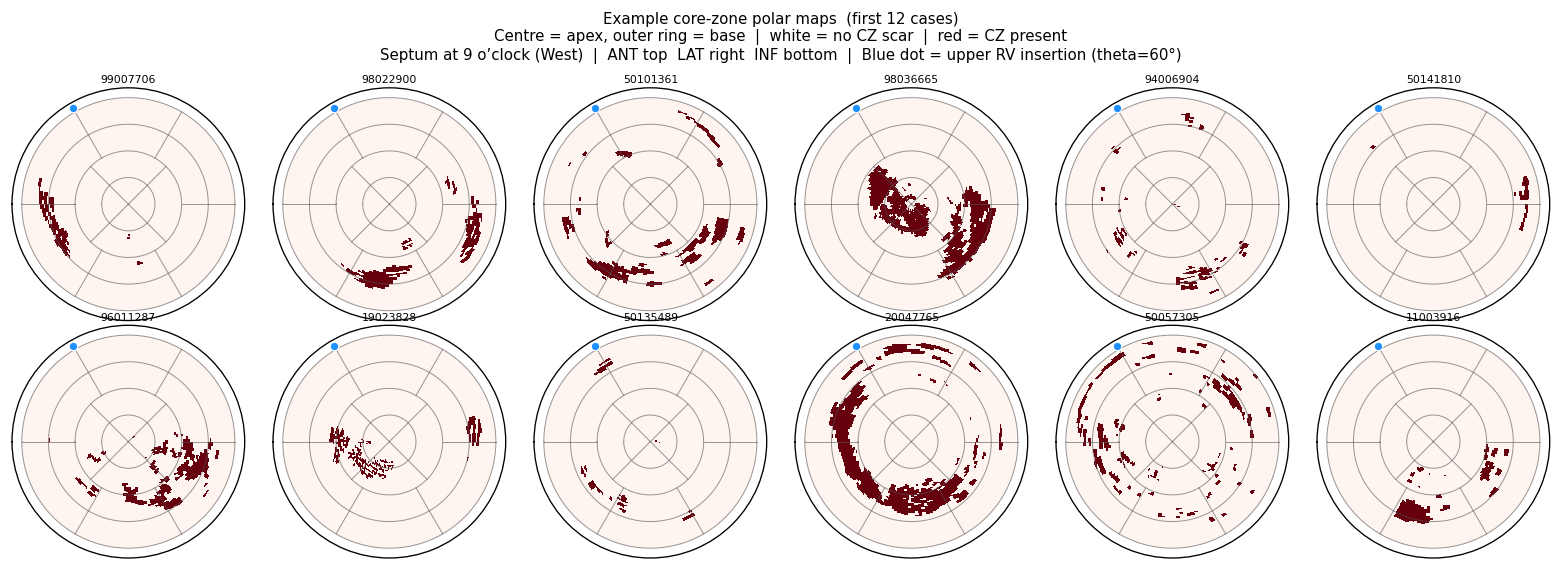

Saved example_polar_maps.png


In [40]:

# Show first N cases with available polar maps as bullseye plots (M03 style)
_SHOW_N  = 12
_NCOLS   = 6
_pm_keys = list(pmaps.keys())[:_SHOW_N]
_nrows   = int(np.ceil(len(_pm_keys) / _NCOLS))

fig = plt.figure(figsize=(_NCOLS * 2.2, _nrows * 2.4))
fig.suptitle(
    f'Example core-zone polar maps  (first {len(_pm_keys)} cases)\n'
    'Centre = apex, outer ring = base  |  white = no CZ scar  |  red = CZ present\n'
    'Septum at 9 o’clock (West)  |  ANT top  LAT right  INF bottom  |  '
    'Blue dot = upper RV insertion (theta=60°)',
    fontsize=9,
)

for idx, key in enumerate(_pm_keys):
    ax = fig.add_subplot(_nrows, _NCOLS, idx + 1, projection='polar')
    draw_bullseye_m04(pmaps[key], ax, cmap='Reds', vmax=1.0)
    pid = key.split('/')[-1]
    ax.set_title(pid, fontsize=6.5, pad=3)

plt.tight_layout()
plt.savefig(OUT / 'example_polar_maps.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved example_polar_maps.png')


### 2.3 AHA Segment Grid and Coronary Territory Map

Each polar bin `(r, theta)` is assigned to one of the 17 AHA segments (Cerqueira et al. 2002), then grouped into LAD, RCA, or LCX.

Important: the territories do **not** occupy the same number of polar bins. LAD includes more/larger AHA segments, including the apex, so its denominator is larger. All territory burden values are therefore reported as:

`scar-positive bins in territory / total bins assigned to that territory`

This makes LAD/RCA/LCX comparable as **fractions of each territory affected**, not raw bin counts.

Convention: theta = 0 = septum (West), increasing clockwise.

| Territory | Segments | Wall |
|---|---|---|
| **LAD** | 1, 2, 7, 8, 13, 14, 17 | Anterior, anteroseptal, apical cap |
| **RCA** | 3, 4, 9, 10, 15 | Inferoseptal, inferior |
| **LCX** | 5, 6, 11, 12, 16 | Inferolateral, anterolateral |

In [41]:
def _aha_segment_grid(n_r=N_R, n_theta=N_THETA):
    labels = np.zeros((n_r, n_theta), dtype=np.int64)
    rc = (np.arange(n_r) + 0.5) / n_r
    tc = (np.arange(n_theta) + 0.5) / n_theta * 360.0
    for ri, radius in enumerate(rc):
        for ti, theta_deg in enumerate(tc):
            if radius < 0.25:
                labels[ri, ti] = 17
            elif radius < 0.50:
                if   45  <= theta_deg < 135: labels[ri, ti] = 13
                elif 135 <= theta_deg < 225: labels[ri, ti] = 16
                elif 225 <= theta_deg < 315: labels[ri, ti] = 15
                else:                        labels[ri, ti] = 14
            elif radius < 0.75:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 8
                elif 60  <= theta_deg < 120: labels[ri, ti] = 7
                elif 120 <= theta_deg < 180: labels[ri, ti] = 12
                elif 180 <= theta_deg < 240: labels[ri, ti] = 11
                elif 240 <= theta_deg < 300: labels[ri, ti] = 10
                else:                        labels[ri, ti] = 9
            else:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 2
                elif 60  <= theta_deg < 120: labels[ri, ti] = 1
                elif 120 <= theta_deg < 180: labels[ri, ti] = 6
                elif 180 <= theta_deg < 240: labels[ri, ti] = 5
                elif 240 <= theta_deg < 300: labels[ri, ti] = 4
                else:                        labels[ri, ti] = 3
    return labels


AHA_GRID = _aha_segment_grid()

SEG_LABELS = {
    1:'bas ant',  2:'bas ant-sep', 3:'bas inf-sep', 4:'bas inf',
    5:'bas inf-lat', 6:'bas ant-lat',
    7:'mid ant',  8:'mid ant-sep', 9:'mid inf-sep', 10:'mid inf',
    11:'mid inf-lat', 12:'mid ant-lat',
    13:'api ant', 14:'api sep',   15:'api inf',    16:'api lat', 17:'apex',
}

TERRITORY = {
    'LAD': [1, 2, 7, 8, 13, 14, 17],
    'RCA': [3, 4, 9, 10, 15],
    'LCX': [5, 6, 11, 12, 16],
}

SEG_TERRITORY = {s: t for t, segs in TERRITORY.items() for s in segs}

TERRITORY_GRID = np.full((N_R, N_THETA), '', dtype=object)
for terr, segs in TERRITORY.items():
    for seg in segs:
        TERRITORY_GRID[AHA_GRID == seg] = terr

# Number of polar bins per territory (denominator for scar burden)
TERR_NBINS = {t: int((TERRITORY_GRID == t).sum()) for t in TERRITORY}

print('Polar-bin denominator per coronary territory:')
for t, n in TERR_NBINS.items():
    print(f'  {t}: {n} polar bins ({100*n/(N_R*N_THETA):.1f}% of the 64x128 grid)')
print('These denominators are used to report territory burden as a fraction of each territory, not as raw size.')

Polar-bin denominator per coronary territory:
  LAD: 4448 polar bins (54.3% of the 64x128 grid)
  RCA: 1888 polar bins (23.0% of the 64x128 grid)
  LCX: 1856 polar bins (22.7% of the 64x128 grid)
These denominators are used to report territory burden as a fraction of each territory, not as raw size.


## Section 3 - Scar Burden

### 3.1 Per-Patient Territory Scar Burden

A core-zone polar map is binary: each polar bin is either scar-positive or not. A scar-positive bin means at least one core-zone mesh vertex projected into that spatial bin. Territory burden is the fraction of each coronary territory occupied by scar-positive bins.

A territory is counted as involved when at least `SCAR_THRESH = 0.02` (2%) of that territory is scar-positive. This lower threshold is useful because post-MI scars can be spatially small but still clinically meaningful, and scars can span more than one territory.

In [42]:
rows = []
for key, pm in pmaps.items():
    pid = key.split('/')[-1]

    # Territory burden: scar-positive polar bins / total territory bins
    terr_burden = {}
    terr_cz_bins = {}
    for terr in TERRITORY:
        mask = (TERRITORY_GRID == terr)
        n_cz = int(pm[mask].sum())
        terr_cz_bins[terr] = n_cz
        terr_burden[terr]  = n_cz / TERR_NBINS[terr]

    dominant   = max(terr_burden, key=lambda t: terr_burden[t])
    n_involved = sum(1 for v in terr_burden.values() if v >= SCAR_THRESH)

    row = {
        'key':        key,
        'pid':        pid,
        'sex':        sex_map.get(pid, np.nan),
        'age':        float(age_map[pid])    if pid in age_map    else np.nan,
        'core_pct':   float(core_pct_map[pid]) if pid in core_pct_map else np.nan,
        'bz_core_pct': float(bz_core_pct_map[pid]) if pid in bz_core_pct_map else np.nan,
        'core_g':     float(core_g_map[pid]) if pid in core_g_map else np.nan,
        'LAD':        terr_burden['LAD'],
        'RCA':        terr_burden['RCA'],
        'LCX':        terr_burden['LCX'],
        'LAD_cz_bins': terr_cz_bins['LAD'],
        'RCA_cz_bins': terr_cz_bins['RCA'],
        'LCX_cz_bins': terr_cz_bins['LCX'],
        'dominant':   dominant,
        'n_involved': n_involved,
        'total_scar': float(pm.mean()),
    }
    rows.append(row)

df = pd.DataFrame(rows)

n_analysis = len(df)
n_sex_analysis = int(df['sex'].notna().sum())
n_age_analysis = int(df['age'].notna().sum())
n_both_analysis = int((df['sex'].notna() & df['age'].notna()).sum())
n_either_analysis = int((df['sex'].notna() | df['age'].notna()).sum())
n_neither_analysis = int((df['sex'].isna() & df['age'].isna()).sum())

analysis_label_summary = pd.DataFrame([
    {'cohort': 'analysis patients with polar maps', 'label': 'sex', 'n_patients': n_sex_analysis,
     'percent_of_analysis_cohort': 100 * n_sex_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'age', 'n_patients': n_age_analysis,
     'percent_of_analysis_cohort': 100 * n_age_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'both_sex_and_age', 'n_patients': n_both_analysis,
     'percent_of_analysis_cohort': 100 * n_both_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'sex_or_age', 'n_patients': n_either_analysis,
     'percent_of_analysis_cohort': 100 * n_either_analysis / max(n_analysis, 1)},
    {'cohort': 'analysis patients with polar maps', 'label': 'neither_sex_nor_age', 'n_patients': n_neither_analysis,
     'percent_of_analysis_cohort': 100 * n_neither_analysis / max(n_analysis, 1)},
])

print(f'Patients in scar-analysis cohort: {n_analysis}')
print(f'  Patients with sex labels: {n_sex_analysis} / {n_analysis} ({100*n_sex_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with age labels: {n_age_analysis} / {n_analysis} ({100*n_age_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with both sex and age labels: {n_both_analysis} / {n_analysis} ({100*n_both_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with either sex or age label: {n_either_analysis} / {n_analysis} ({100*n_either_analysis/max(n_analysis,1):.1f}%)')
print(f'  Patients with neither label: {n_neither_analysis} / {n_analysis} ({100*n_neither_analysis/max(n_analysis,1):.1f}%)')
print(f'core_pct known: {df["core_pct"].notna().sum()}')
display(analysis_label_summary)
analysis_label_summary.to_csv(OUT / 'analysis_label_availability.csv', index=False)
print('Saved analysis_label_availability.csv')
print('\nTerritory burden (mean +/- SD across patients) [scar-positive polar bins / territory denominator]:')
for terr in ('LAD', 'RCA', 'LCX'):
    mean_b = df[terr].mean()
    std_b  = df[terr].std()
    mean_cz = df[f'{terr}_cz_bins'].mean()
    denom   = TERR_NBINS[terr]
    print(f'  {terr}: {mean_b:.4f} +/- {std_b:.4f}  '
          f'(mean scar-positive bins: {mean_cz:.1f} / {denom})')
print(f'\nDominant territory:')
print(df['dominant'].value_counts().to_string())
print(f'\nTerritories involved (threshold={SCAR_THRESH:.2f} = {100*SCAR_THRESH:.0f}% of territory scar-positive):')
print(df['n_involved'].value_counts().sort_index().to_string())

Patients in scar-analysis cohort: 84
  Patients with sex labels: 32 / 84 (38.1%)
  Patients with age labels: 32 / 84 (38.1%)
  Patients with both sex and age labels: 32 / 84 (38.1%)
  Patients with either sex or age label: 32 / 84 (38.1%)
  Patients with neither label: 52 / 84 (61.9%)
core_pct known: 63


,cohort,label,n_patients,percent_of_analysis_cohort
0,analysis patients with polar maps,sex,32,38.095238
1,analysis patients with polar maps,age,32,38.095238
2,analysis patients with polar maps,both_sex_and_age,32,38.095238
3,analysis patients with polar maps,sex_or_age,32,38.095238
4,analysis patients with polar maps,neither_sex_nor_age,52,61.904762


Saved analysis_label_availability.csv

Territory burden (mean +/- SD across patients) [scar-positive polar bins / territory denominator]:
  LAD: 0.0534 +/- 0.0838  (mean scar-positive bins: 237.5 / 4448)
  RCA: 0.0466 +/- 0.0543  (mean scar-positive bins: 88.0 / 1888)
  LCX: 0.0507 +/- 0.0619  (mean scar-positive bins: 94.1 / 1856)

Dominant territory:
dominant
LCX    32
LAD    28
RCA    24

Territories involved (threshold=0.02 = 2% of territory scar-positive):
n_involved
0     7
1    31
2    35
3    11


### 3.2 Analysis 1 - Population-Level Scar Characterization

This section translates each patient polar map into the 17 AHA segments. For each segment, the value is the fraction of bins in that segment containing core-zone scar. These segment vectors are the basis for the normality checks, sex comparisons, age correlations, PCA, permutation tests, and bootstrap confidence intervals below.

In [43]:
SEGMENTS = list(range(1, 18))
SEG_COLS = [f'seg_{s:02d}' for s in SEGMENTS]

seg_rows = []
for key, pm in pmaps.items():
    pid = key.split('/')[-1]
    row = {
        'key': key,
        'pid': pid,
        'sex': sex_map.get(pid, np.nan),
        'age': float(age_map[pid]) if pid in age_map else np.nan,
        'total_scar': float(np.asarray(pm, dtype=float).mean()),
    }
    for seg, col in zip(SEGMENTS, SEG_COLS):
        mask = (AHA_GRID == seg)
        row[col] = float(np.asarray(pm, dtype=float)[mask].mean())
    seg_rows.append(row)

seg_df = pd.DataFrame(seg_rows)
seg_matrix = seg_df[SEG_COLS].to_numpy(dtype=float) if len(seg_df) else np.empty((0, len(SEG_COLS)))

# Add segment columns to df for convenient downstream joins without changing existing territory logic.
if len(df) and len(seg_df):
    df = df.merge(seg_df[['key', *SEG_COLS]], on='key', how='left', suffixes=('', '_aha'))

age_desc = seg_df['age'].dropna()
sex_counts = seg_df['sex'].value_counts(dropna=True).rename_axis('sex').reset_index(name='n')
sex_counts['percent'] = 100 * sex_counts['n'] / max(int(sex_counts['n'].sum()), 1)

seg_summary = []
for seg, col in zip(SEGMENTS, SEG_COLS):
    vals = seg_df[col].dropna()
    pos = vals[vals > 0]
    seg_summary.append({
        'segment': seg,
        'label': SEG_LABELS[seg],
        'n_patients': int(vals.size),
        'n_with_scar': int((vals > 0).sum()),
        'pct_with_scar': 100 * float((vals > 0).mean()) if vals.size else np.nan,
        'mean_extent_all': float(vals.mean()) if vals.size else np.nan,
        'sd_extent_all': float(vals.std(ddof=1)) if vals.size > 1 else np.nan,
        'median_extent_all': float(vals.median()) if vals.size else np.nan,
        'mean_extent_positive': float(pos.mean()) if len(pos) else 0.0,
        'median_extent_positive': float(pos.median()) if len(pos) else 0.0,
    })
seg_summary = pd.DataFrame(seg_summary)

print(f'Cohort with AHA segment vectors: n={len(seg_df)}')
print(f'  Patients with sex labels: {int(seg_df["sex"].notna().sum())} / {len(seg_df)} '
      f'({100*seg_df["sex"].notna().sum()/max(len(seg_df),1):.1f}%)')
print(f'  Patients with age labels: {int(seg_df["age"].notna().sum())} / {len(seg_df)} '
      f'({100*seg_df["age"].notna().sum()/max(len(seg_df),1):.1f}%)')
print(f'  Patients with both sex and age labels: '
      f'{int((seg_df["sex"].notna() & seg_df["age"].notna()).sum())} / {len(seg_df)} '
      f'({100*(seg_df["sex"].notna() & seg_df["age"].notna()).sum()/max(len(seg_df),1):.1f}%)')
if len(age_desc):
    print(f'Age: mean={age_desc.mean():.1f} +/- {age_desc.std(ddof=1):.1f} years  '
          f'(median={age_desc.median():.1f}, n={len(age_desc)})')
else:
    print('Age: no available values')
print('\nSex distribution:')
print(sex_counts.to_string(index=False) if len(sex_counts) else 'No sex labels available')
print('\nPer-segment scar summary:')
display(seg_summary)

seg_summary.to_csv(OUT / 'aha17_segment_summary.csv', index=False)
print('Saved aha17_segment_summary.csv')

Cohort with AHA segment vectors: n=84
  Patients with sex labels: 32 / 84 (38.1%)
  Patients with age labels: 32 / 84 (38.1%)
  Patients with both sex and age labels: 32 / 84 (38.1%)
Age: mean=64.6 +/- 9.5 years  (median=64.0, n=32)

Sex distribution:
sex  n  percent
  M 27   84.375
  F  5   15.625

Per-segment scar summary:


,segment,label,n_patients,n_with_scar,pct_with_scar,mean_extent_all,sd_extent_all,median_extent_all,mean_extent_positive,median_extent_positive
0,1,bas ant,84,22,26.190476,0.019683,0.061134,0.000000,0.075155,0.035511
1,2,bas ant-sep,84,33,39.285714,0.020833,0.044558,0.000000,0.053030,0.029762
2,3,bas inf-sep,84,21,25.000000,0.015873,0.056909,0.000000,0.063492,0.032738
3,4,bas inf,84,26,30.952381,0.013427,0.036744,0.000000,0.043378,0.024148
4,5,bas inf-lat,84,38,45.238095,0.028097,0.051199,0.000000,0.062108,0.029762
5,6,bas ant-lat,84,29,34.523810,0.029585,0.062519,0.000000,0.085694,0.065476
6,7,mid ant,84,29,34.523810,0.044237,0.116281,0.000000,0.128135,0.048295
7,8,mid ant-sep,84,43,51.190476,0.067177,0.135003,0.002976,0.131229,0.083333
8,9,mid inf-sep,84,47,55.952381,0.062571,0.107858,0.011905,0.111829,0.065476
9,10,mid inf,84,50,59.523810,0.079444,0.136945,0.019886,0.133466,0.076705


Saved aha17_segment_summary.csv


### 3.3 Analysis 2 - AHA-17 Within-Patient Segment Comparison

**Analysis 2.** This tests whether scar is uniformly distributed across the 17 AHA segments.

Each patient contributes 17 paired values, one per segment, so this is a within-patient repeated-measures problem. The global test is the **Friedman test**, a non-parametric alternative to repeated-measures ANOVA.

Null hypothesis: the 17 AHA segments have the same scar-burden distribution.

If the global p-value is small, scar has a spatial preference across the ventricle. Pairwise post-hoc tests are optional and are corrected here with Bonferroni because there are many segment pairs.

AHA-17 within-patient Friedman test: chi2=98.98, p=5.371e-14, n=84
Null hypothesis: all 17 AHA segments have the same scar-burden distribution.
Interpretation: small p-value => scar burden is spatially non-uniform across AHA segments.


,segment,label,mean_extent_all,sd_extent_all,median_extent_all,pct_with_scar
10,11,mid inf-lat,0.093537,0.158894,0.011905,55.952381
13,14,api sep,0.086891,0.185619,0.000000,44.047619
9,10,mid inf,0.079444,0.136945,0.019886,59.523810
12,13,api ant,0.071498,0.163602,0.000000,41.666667
7,8,mid ant-sep,0.067177,0.135003,0.002976,51.190476
8,9,mid inf-sep,0.062571,0.107858,0.011905,55.952381
14,15,api inf,0.056641,0.089096,0.009766,54.761905
11,12,mid ant-lat,0.053890,0.107102,0.000000,46.428571
16,17,apex,0.050921,0.111588,0.006592,57.142857
15,16,api lat,0.049200,0.089899,0.000000,46.428571


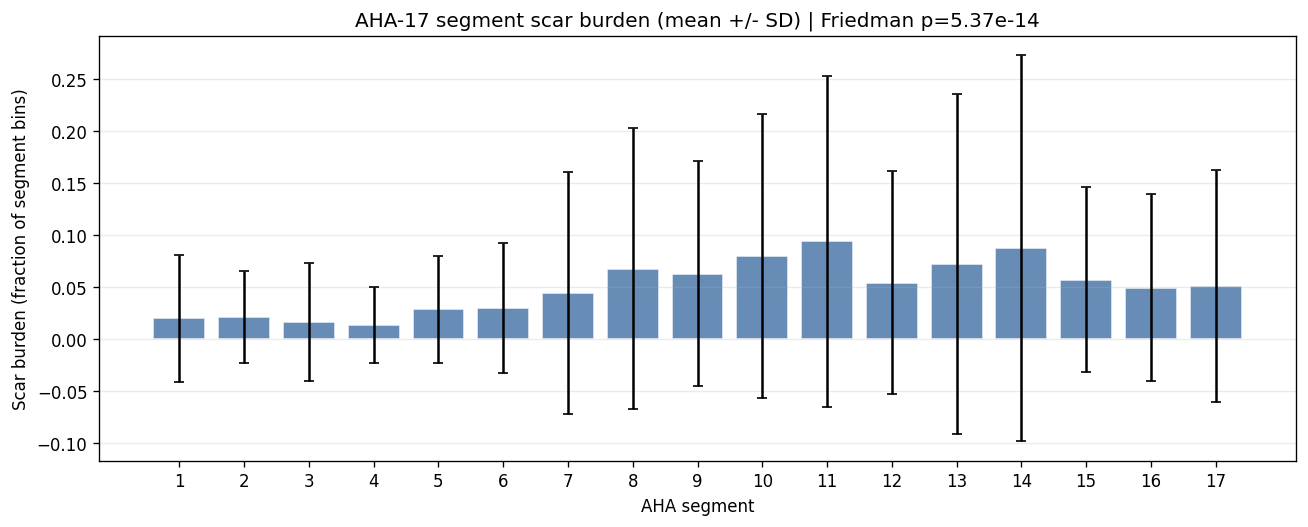

Saved aha17_within_patient_friedman.png
Saved aha17_segment_comparison_ranked.csv and aha17_pairwise_wilcoxon_bonferroni.csv


In [44]:
aha_complete = seg_df.dropna(subset=SEG_COLS).copy()
if len(aha_complete) >= 3:
    aha_values = [aha_complete[col].to_numpy(dtype=float) for col in SEG_COLS]
    aha_fr_stat, aha_fr_p = friedmanchisquare(*aha_values)

    aha_segment_comparison = seg_summary[['segment', 'label', 'mean_extent_all', 'sd_extent_all',
                                           'median_extent_all', 'pct_with_scar']].copy()
    aha_segment_comparison = aha_segment_comparison.sort_values('mean_extent_all', ascending=False)

    print(f'AHA-17 within-patient Friedman test: chi2={aha_fr_stat:.2f}, p={aha_fr_p:.4g}, n={len(aha_complete)}')
    print('Null hypothesis: all 17 AHA segments have the same scar-burden distribution.')
    print('Interpretation: small p-value => scar burden is spatially non-uniform across AHA segments.')
    display(aha_segment_comparison)

    pair_rows = []
    for ii, (seg_i, col_i) in enumerate(zip(SEGMENTS, SEG_COLS)):
        for seg_j, col_j in zip(SEGMENTS[ii + 1:], SEG_COLS[ii + 1:]):
            x = aha_complete[col_i].to_numpy(dtype=float)
            y = aha_complete[col_j].to_numpy(dtype=float)
            diff = x - y
            if np.allclose(diff, 0):
                stat, p_pair = 0.0, 1.0
            else:
                stat, p_pair = wilcoxon(x, y, zero_method='zsplit', alternative='two-sided')
            pair_rows.append({
                'segment_a': seg_i,
                'label_a': SEG_LABELS[seg_i],
                'segment_b': seg_j,
                'label_b': SEG_LABELS[seg_j],
                'mean_diff_a_minus_b': float(np.nanmean(diff)),
                'wilcoxon_stat': stat,
                'p_uncorrected': p_pair,
            })
    aha_pairwise = pd.DataFrame(pair_rows)
    n_pairs = len(aha_pairwise)
    aha_pairwise['p_bonferroni'] = np.minimum(aha_pairwise['p_uncorrected'] * n_pairs, 1.0)
    aha_pairwise['significant_bonf_0_05'] = aha_pairwise['p_bonferroni'] < 0.05

    fig_aha_cmp, ax_aha_cmp = plt.subplots(figsize=(11, 4.5))
    plot_df = seg_summary.sort_values('segment')
    ax_aha_cmp.bar(plot_df['segment'], plot_df['mean_extent_all'],
                   yerr=plot_df['sd_extent_all'], capsize=3,
                   color='#4c78a8', edgecolor='white', alpha=0.85)
    ax_aha_cmp.set_xticks(SEGMENTS)
    ax_aha_cmp.set_xlabel('AHA segment')
    ax_aha_cmp.set_ylabel('Scar burden (fraction of segment bins)')
    ax_aha_cmp.set_title(f'AHA-17 segment scar burden (mean +/- SD) | Friedman p={aha_fr_p:.3g}')
    ax_aha_cmp.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'aha17_within_patient_friedman.png', bbox_inches='tight', dpi=150)
    plt.show()

    aha_segment_comparison.to_csv(OUT / 'aha17_segment_comparison_ranked.csv', index=False)
    aha_pairwise.to_csv(OUT / 'aha17_pairwise_wilcoxon_bonferroni.csv', index=False)
    print('Saved aha17_within_patient_friedman.png')
    print('Saved aha17_segment_comparison_ranked.csv and aha17_pairwise_wilcoxon_bonferroni.csv')
else:
    print(f'Skipping AHA-17 Friedman test: only {len(aha_complete)} complete patient vectors available.')

### 3.4 Analysis 1 - Population Scar Atlas and Bootstrap Confidence Intervals

The atlas maps the average scar burden per AHA segment across patients.

Bootstrap is used because scar burden is bounded, sparse, and non-normal. "Resampling 84 patients with replacement" means each bootstrap sample has the same size as the cohort, but patients are sampled randomly from the observed cohort and a patient can appear more than once while another can be absent. For each resample, the mean scar burden is recomputed. After 2000 resamples, the 2.5th and 97.5th percentiles form the 95% confidence interval.

So `Bootstrap CI lower/upper` is not a new scar map from another dataset; it is the uncertainty range around the estimated population mean segment burden.

C:\Users\joan\AppData\Local\Temp\ipykernel_28024\300595265.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


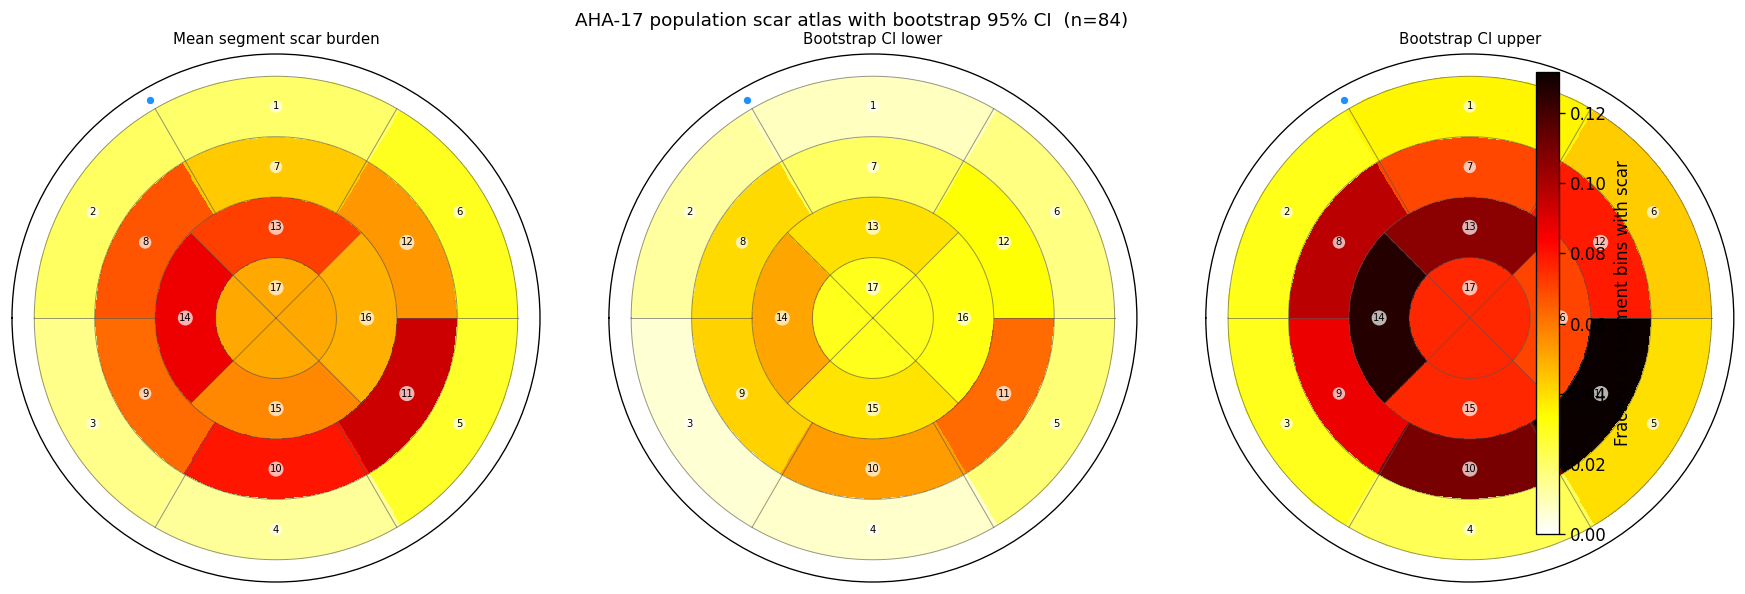

Saved aha17_population_scar_atlas_bootstrap_ci.png


C:\Users\joan\AppData\Local\Temp\ipykernel_28024\300595265.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


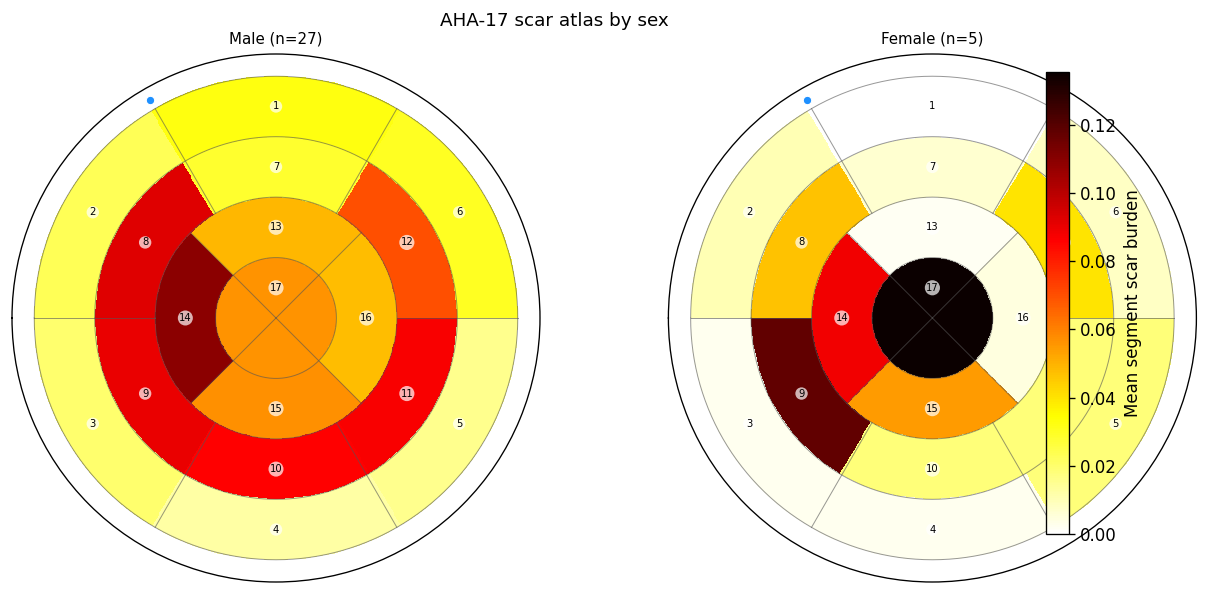

Saved aha17_scar_atlas_by_sex.png


In [45]:
def bootstrap_ci(data, statistic=np.nanmean, n_boot=2000, ci=95, rng=None):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(42) if rng is None else rng
    idx = rng.integers(0, data.size, size=(n_boot, data.size))
    boot = np.apply_along_axis(statistic, 1, data[idx])
    alpha = (100 - ci) / 2
    return tuple(np.nanpercentile(boot, [alpha, 100 - alpha]))

rng_boot = np.random.default_rng(42)
seg_boot = []
for seg, col in zip(SEGMENTS, SEG_COLS):
    vals = seg_df[col].to_numpy(dtype=float)
    lo, hi = bootstrap_ci(vals, np.nanmean, n_boot=2000, rng=rng_boot)
    seg_boot.append({'segment': seg, 'mean_extent': np.nanmean(vals), 'ci95_low': lo, 'ci95_high': hi})
seg_boot = pd.DataFrame(seg_boot)
seg_summary = seg_summary.merge(seg_boot, on='segment', how='left')

atlas_grid = np.zeros_like(AHA_GRID, dtype=float)
ci_low_grid = np.zeros_like(AHA_GRID, dtype=float)
ci_high_grid = np.zeros_like(AHA_GRID, dtype=float)
for _, row in seg_boot.iterrows():
    mask = (AHA_GRID == int(row['segment']))
    atlas_grid[mask] = row['mean_extent']
    ci_low_grid[mask] = row['ci95_low']
    ci_high_grid[mask] = row['ci95_high']

fig_atlas, axes_atlas = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': 'polar'})
fig_atlas.suptitle(f'AHA-17 population scar atlas with bootstrap 95% CI  (n={len(seg_df)})', fontsize=11)
vmax_atlas = max(float(np.nanmax(ci_high_grid)), 1e-9)
for ax, arr, title in zip(
    axes_atlas,
    [atlas_grid, ci_low_grid, ci_high_grid],
    ['Mean segment scar burden', 'Bootstrap CI lower', 'Bootstrap CI upper'],
):
    m = draw_bullseye_m04(arr, ax, title=title, cmap='hot_r', vmax=vmax_atlas, label_segs=True)
plt.colorbar(m, ax=axes_atlas, fraction=0.026, pad=0.08, label='Fraction of segment bins with scar')
plt.tight_layout()
plt.savefig(OUT / 'aha17_population_scar_atlas_bootstrap_ci.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved aha17_population_scar_atlas_bootstrap_ci.png')

if seg_df['sex'].notna().any():
    sex_levels = [s for s in ['M', 'F'] if (seg_df['sex'] == s).any()]
    fig_satlas, axes_satlas = plt.subplots(1, len(sex_levels), figsize=(5.5 * len(sex_levels), 5),
                                           subplot_kw={'projection': 'polar'})
    axes_satlas = np.atleast_1d(axes_satlas)
    vmax_sex = 1e-9
    sex_maps = {}
    for sx in sex_levels:
        sub = seg_df[seg_df['sex'] == sx]
        grid = np.zeros_like(AHA_GRID, dtype=float)
        for seg, col in zip(SEGMENTS, SEG_COLS):
            grid[AHA_GRID == seg] = sub[col].mean()
        sex_maps[sx] = grid
        vmax_sex = max(vmax_sex, float(np.nanmax(grid)))
    for ax, sx in zip(axes_satlas, sex_levels):
        title = f'{"Male" if sx == "M" else "Female"} (n={(seg_df["sex"] == sx).sum()})'
        m = draw_bullseye_m04(sex_maps[sx], ax, title=title, cmap='hot_r', vmax=vmax_sex, label_segs=True)
    plt.colorbar(m, ax=axes_satlas, fraction=0.036, pad=0.08, label='Mean segment scar burden')
    fig_satlas.suptitle('AHA-17 scar atlas by sex', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT / 'aha17_scar_atlas_by_sex.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved aha17_scar_atlas_by_sex.png')

## Section 4 - Statistical and Transmurality Analysis

### 4.1 Normality Diagnostics

This section documents whether parametric assumptions are plausible before using Hotelling T2 / MANOVA-style F tests.

Diagnostics included:
- QQ-plots + Shapiro-Wilk for scalar variables: age, total scar, LAD, RCA, LCX.
- Shapiro-Wilk table for all 17 AHA segment variables, without plotting 17 separate QQ-plots.
- Multivariate chi-square QQ plots of Mahalanobis distances for the AHA-17 scar vector and the LAD/RCA/LCX territory vector.
- Sex-stratified scalar normality checks where sample size allows.
- A descriptive covariance check for male vs female AHA-17 and territory vectors.

If normality/covariance assumptions look poor, parametric F p-values should be treated as exploratory and permutation/non-parametric tests should be used as the main evidence.

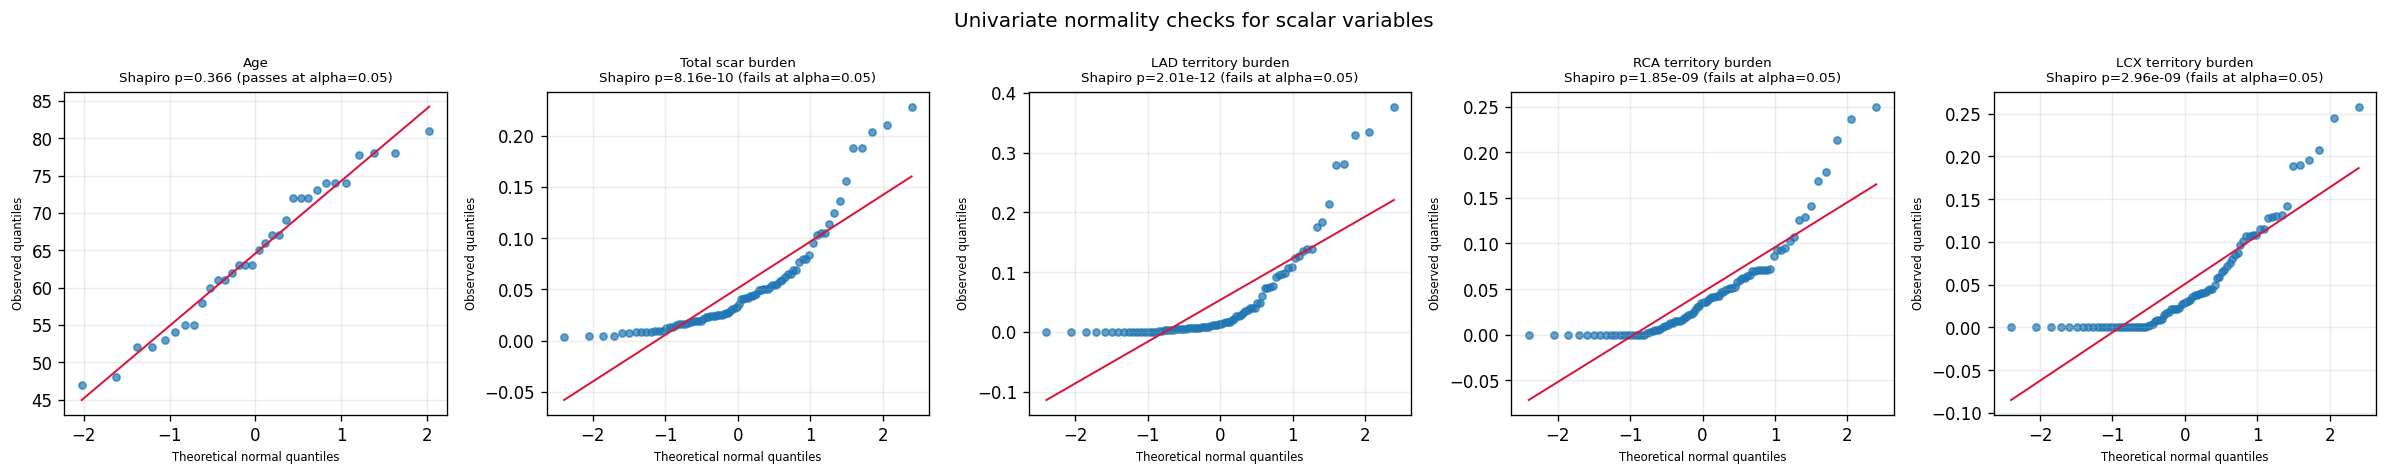

Saved normality_qq_scalar_variables.png
Normality summary (scalar variables + AHA-17 table):


,variable,group,n,shapiro_p,passes_0_05,segment,label
0,age,all,32,3.660392e-01,True,NaN,NaN
1,total_scar,all,84,8.163205e-10,False,NaN,NaN
2,LAD,all,84,2.005276e-12,False,NaN,NaN
3,RCA,all,84,1.853320e-09,False,NaN,NaN
4,LCX,all,84,2.956117e-09,False,NaN,NaN
5,seg_01,all,84,2.897333e-17,False,1.0,bas ant
6,seg_02,all,84,8.847204e-15,False,2.0,bas ant-sep
7,seg_03,all,84,4.444092e-18,False,3.0,bas inf-sep
8,seg_04,all,84,1.177742e-16,False,4.0,bas inf
9,seg_05,all,84,2.449489e-13,False,5.0,bas inf-lat


AHA-17 segments passing Shapiro alpha=0.05: 0 / 17
Saved normality_shapiro_scalar_aha17_summary.csv


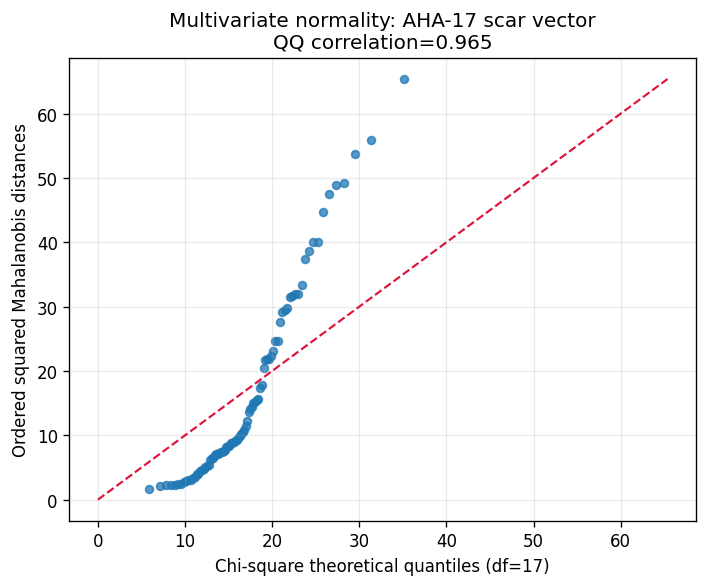

Saved normality_chisquare_aha17.png


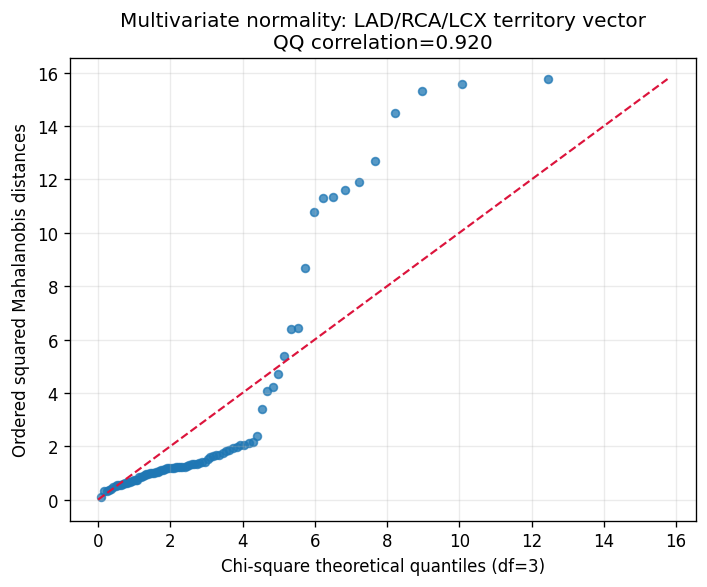

Saved normality_chisquare_territories.png


,analysis,n,p_variables,qq_correlation,status
0,Multivariate normality: AHA-17 scar vector,84,17,0.965362,computed
1,Multivariate normality: LAD/RCA/LCX territory ...,84,3,0.920359,computed


Saved normality_multivariate_summary.csv
Sex-stratified scalar normality checks:


,group,variable,n,shapiro_p,passes_0_05
0,M,total_scar,27,0.000446,False
1,M,LAD,27,0.000079,False
2,M,RCA,27,0.000084,False
3,M,LCX,27,0.001750,False
4,F,total_scar,5,0.000675,False
5,F,LAD,5,0.000187,False
6,F,RCA,5,0.353341,True
7,F,LCX,5,0.342452,True


Saved normality_by_sex_scalar_summary.csv
Descriptive covariance diagnostics for sex-group multivariate tests:


,analysis,n_male,n_female,p_variables,trace_cov_male,trace_cov_female,trace_ratio_larger_over_smaller,regularized_det_male,regularized_det_female,relative_frobenius_cov_difference,status
0,AHA-17 scar vector by sex,27,5,17,0.208783,0.172097,1.213167,1.946630e-44,1.104891e-112,0.903147,descriptive_only
1,LAD/RCA/LCX territory vector by sex,27,5,3,0.012234,0.030195,2.468113,5.345834e-08,3.699366e-09,0.816084,descriptive_only


Saved normality_covariance_diagnostics_by_sex.csv

Decision note: if Shapiro/QQ and covariance diagnostics look poor, use permutation p-values and non-parametric tests as the main results; keep parametric F tests as exploratory summaries.


In [46]:
_NORMALITY_ALPHA = 0.05


def _shapiro_result(values, alpha=_NORMALITY_ALPHA):
    values = pd.Series(values).dropna().astype(float).to_numpy()
    if len(values) < 3:
        return np.nan, len(values), False
    p_val = shapiro(values).pvalue if len(values) <= 5000 else np.nan
    return p_val, len(values), bool(np.isfinite(p_val) and p_val >= alpha)


def _qq_on_axis(ax, values, title, alpha=_NORMALITY_ALPHA):
    values = pd.Series(values).dropna().astype(float).to_numpy()
    if len(values) < 3:
        ax.text(0.5, 0.5, 'n < 3', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return np.nan
    osm, osr = probplot(values, dist='norm', fit=False)
    slope, intercept = np.polyfit(osm, osr, 1)
    ax.scatter(osm, osr, s=18, alpha=0.70)
    ax.plot(osm, slope * np.asarray(osm) + intercept, color='crimson', lw=1.2)
    p_val, _, passes = _shapiro_result(values, alpha=alpha)
    status = 'passes' if passes else 'fails'
    ax.set_title(f'{title}\nShapiro p={p_val:.3g} ({status} at alpha={alpha})', fontsize=8)
    ax.set_xlabel('Theoretical normal quantiles', fontsize=7)
    ax.set_ylabel('Observed quantiles', fontsize=7)
    ax.grid(alpha=0.25)
    return p_val


def _mahalanobis_chisquare_qq(X, title, out_name, variable_names=None, ridge=1e-8):
    X = np.asarray(X, dtype=float)
    X = X[np.isfinite(X).all(axis=1)]
    if X.shape[0] <= X.shape[1] or X.shape[0] < 5:
        print(f'Skipping {title}: n={X.shape[0]} <= p={X.shape[1]} or too few rows')
        return {'analysis': title, 'n': X.shape[0], 'p_variables': X.shape[1], 'status': 'skipped'}

    Xc = X - X.mean(axis=0, keepdims=True)
    cov = np.cov(Xc, rowvar=False)
    scale = np.trace(cov) / max(cov.shape[0], 1)
    cov_reg = cov + np.eye(cov.shape[0]) * ridge * max(scale, 1.0)
    inv_cov = np.linalg.pinv(cov_reg)
    d2 = np.einsum('ij,jk,ik->i', Xc, inv_cov, Xc)
    d2_sorted = np.sort(d2)
    probs = (np.arange(1, len(d2_sorted) + 1) - 0.5) / len(d2_sorted)
    chi_q = chi2.ppf(probs, df=X.shape[1])

    corr = float(np.corrcoef(chi_q, d2_sorted)[0, 1]) if len(d2_sorted) > 2 else np.nan
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(chi_q, d2_sorted, s=22, alpha=0.75)
    lim = max(float(np.nanmax(chi_q)), float(np.nanmax(d2_sorted)))
    ax.plot([0, lim], [0, lim], color='crimson', lw=1.3, ls='--')
    ax.set_xlabel(f'Chi-square theoretical quantiles (df={X.shape[1]})')
    ax.set_ylabel('Ordered squared Mahalanobis distances')
    ax.set_title(f'{title}\nQQ correlation={corr:.3f}')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / out_name, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved {out_name}')
    return {'analysis': title, 'n': X.shape[0], 'p_variables': X.shape[1],
            'qq_correlation': corr, 'status': 'computed'}


def _covariance_diagnostic(X, labels, label_name):
    labels = np.asarray(labels)
    X = np.asarray(X, dtype=float)
    mask = np.isfinite(X).all(axis=1) & pd.Series(labels).isin(['M', 'F']).to_numpy()
    X = X[mask]
    labels = labels[mask]
    Xm = X[labels == 'M']
    Xf = X[labels == 'F']
    if len(Xm) < 2 or len(Xf) < 2:
        return {'analysis': label_name, 'status': 'skipped', 'reason': 'group n < 2'}
    cov_m = np.atleast_2d(np.cov(Xm, rowvar=False))
    cov_f = np.atleast_2d(np.cov(Xf, rowvar=False))
    trace_m = float(np.trace(cov_m))
    trace_f = float(np.trace(cov_f))
    det_m = float(np.linalg.det(cov_m + np.eye(cov_m.shape[0]) * 1e-8))
    det_f = float(np.linalg.det(cov_f + np.eye(cov_f.shape[0]) * 1e-8))
    frob_diff = float(np.linalg.norm(cov_m - cov_f, ord='fro'))
    frob_rel = frob_diff / max(float(np.linalg.norm(cov_m, ord='fro')), float(np.linalg.norm(cov_f, ord='fro')), 1e-12)
    return {
        'analysis': label_name,
        'n_male': len(Xm),
        'n_female': len(Xf),
        'p_variables': X.shape[1],
        'trace_cov_male': trace_m,
        'trace_cov_female': trace_f,
        'trace_ratio_larger_over_smaller': max(trace_m, trace_f) / max(min(trace_m, trace_f), 1e-12),
        'regularized_det_male': det_m,
        'regularized_det_female': det_f,
        'relative_frobenius_cov_difference': frob_rel,
        'status': 'descriptive_only',
    }


# 4.1a: scalar QQ-plots and Shapiro-Wilk.
scalar_specs = [
    ('age', 'Age', seg_df['age']),
    ('total_scar', 'Total scar burden', seg_df['total_scar']),
    ('LAD', 'LAD territory burden', df['LAD']),
    ('RCA', 'RCA territory burden', df['RCA']),
    ('LCX', 'LCX territory burden', df['LCX']),
]
fig_qq, axes_qq = plt.subplots(1, len(scalar_specs), figsize=(4 * len(scalar_specs), 4))
fig_qq.suptitle('Univariate normality checks for scalar variables', fontsize=12)
normality_rows = []
for ax, (var, title, values) in zip(np.atleast_1d(axes_qq), scalar_specs):
    p_val = _qq_on_axis(ax, values, title)
    _, n_var, passes = _shapiro_result(values)
    normality_rows.append({'variable': var, 'group': 'all', 'n': n_var,
                           'shapiro_p': p_val, 'passes_0_05': passes})
plt.tight_layout()
plt.savefig(OUT / 'normality_qq_scalar_variables.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved normality_qq_scalar_variables.png')

# 4.1b: AHA-17 Shapiro table only.
for seg, col in zip(SEGMENTS, SEG_COLS):
    p_val, n_var, passes = _shapiro_result(seg_df[col])
    normality_rows.append({'variable': col, 'segment': seg, 'label': SEG_LABELS[seg],
                           'group': 'all', 'n': n_var, 'shapiro_p': p_val,
                           'passes_0_05': passes})
normality_summary = pd.DataFrame(normality_rows)
print('Normality summary (scalar variables + AHA-17 table):')
display(normality_summary)
print('AHA-17 segments passing Shapiro alpha=0.05:',
      int(normality_summary[normality_summary['variable'].isin(SEG_COLS)]['passes_0_05'].sum()),
      '/', len(SEG_COLS))
normality_summary.to_csv(OUT / 'normality_shapiro_scalar_aha17_summary.csv', index=False)
print('Saved normality_shapiro_scalar_aha17_summary.csv')

# 4.1c: multivariate normality diagnostics.
mv_rows = []
mv_rows.append(_mahalanobis_chisquare_qq(seg_df[SEG_COLS].to_numpy(dtype=float),
                                         'Multivariate normality: AHA-17 scar vector',
                                         'normality_chisquare_aha17.png'))
mv_rows.append(_mahalanobis_chisquare_qq(df[['LAD', 'RCA', 'LCX']].to_numpy(dtype=float),
                                         'Multivariate normality: LAD/RCA/LCX territory vector',
                                         'normality_chisquare_territories.png'))
multivariate_normality_summary = pd.DataFrame(mv_rows)
display(multivariate_normality_summary)
multivariate_normality_summary.to_csv(OUT / 'normality_multivariate_summary.csv', index=False)
print('Saved normality_multivariate_summary.csv')

# 4.1d: sex-stratified scalar normality checks.
sex_norm_rows = []
if 'sex' in df.columns and df['sex'].notna().any():
    for group_label, group_df in [('M', df[df['sex'] == 'M']), ('F', df[df['sex'] == 'F'])]:
        for var in ['total_scar', 'LAD', 'RCA', 'LCX']:
            p_val, n_var, passes = _shapiro_result(group_df[var])
            sex_norm_rows.append({'group': group_label, 'variable': var, 'n': n_var,
                                  'shapiro_p': p_val, 'passes_0_05': passes})
sex_group_normality = pd.DataFrame(sex_norm_rows)
print('Sex-stratified scalar normality checks:')
display(sex_group_normality)
sex_group_normality.to_csv(OUT / 'normality_by_sex_scalar_summary.csv', index=False)
print('Saved normality_by_sex_scalar_summary.csv')

# 4.1e: covariance diagnostics for parametric Hotelling/MANOVA-style tests.
cov_rows = []
sex_seg_for_cov = seg_df.dropna(subset=['sex']).copy()
sex_seg_for_cov = sex_seg_for_cov[sex_seg_for_cov['sex'].isin(['M', 'F'])]
if len(sex_seg_for_cov):
    cov_rows.append(_covariance_diagnostic(sex_seg_for_cov[SEG_COLS].to_numpy(dtype=float),
                                           sex_seg_for_cov['sex'].to_numpy(),
                                           'AHA-17 scar vector by sex'))
sex_df_for_cov = df.dropna(subset=['sex']).copy()
sex_df_for_cov = sex_df_for_cov[sex_df_for_cov['sex'].isin(['M', 'F'])]
if len(sex_df_for_cov):
    cov_rows.append(_covariance_diagnostic(sex_df_for_cov[['LAD', 'RCA', 'LCX']].to_numpy(dtype=float),
                                           sex_df_for_cov['sex'].to_numpy(),
                                           'LAD/RCA/LCX territory vector by sex'))
covariance_diagnostics = pd.DataFrame(cov_rows)
print('Descriptive covariance diagnostics for sex-group multivariate tests:')
display(covariance_diagnostics)
covariance_diagnostics.to_csv(OUT / 'normality_covariance_diagnostics_by_sex.csv', index=False)
print('Saved normality_covariance_diagnostics_by_sex.csv')

print('\nDecision note: if Shapiro/QQ and covariance diagnostics look poor, use permutation p-values and non-parametric tests as the main results; keep parametric F tests as exploratory summaries.')

### 4.2 Analysis 4 - Sex Differences: Mann-Whitney, Permutation, and Hotelling T2

This is exploratory because the sex-labeled subset is unbalanced: many more males than females. The solutions used here are:

1. **Univariate segment tests:** Mann-Whitney U per AHA segment, with Bonferroni correction across 17 tests. This avoids normality assumptions.
2. **Multivariate sex test:** two-sample Hotelling T2 / two-group MANOVA-style test using the unequal-sample pooled within-group covariance matrix:

`S_pooled = ((n_male - 1) cov_male + (n_female - 1) cov_female) / (n_male + n_female - 2)`

This is the weighted average covariance matrix you remembered. It gives more weight to the larger group's covariance while still estimating a shared within-group covariance.

The parametric Hotelling F-test assumes multivariate normality and similar covariance matrices, which are fragile here. Therefore, the notebook also reports a **permutation p-value** that preserves the male/female group sizes and does not rely on multivariate normality.

In [ ]:
def _pooled_covariance_two_groups(X, labels, pos='M', neg='F', ridge=1e-8):
    labels = np.asarray(labels)
    X = np.asarray(X, dtype=float)
    Xa = X[labels == pos]
    Xb = X[labels == neg]
    if len(Xa) < 2 or len(Xb) < 2:
        raise ValueError('Both groups need at least two observations.')

    n_a, n_b = len(Xa), len(Xb)
    p_dim = X.shape[1]
    mean_a = Xa.mean(axis=0)
    mean_b = Xb.mean(axis=0)
    grand = X.mean(axis=0)

    cov_a = np.cov(Xa, rowvar=False)
    cov_b = np.cov(Xb, rowvar=False)
    cov_a = np.atleast_2d(cov_a)
    cov_b = np.atleast_2d(cov_b)

    # Within-group SSCP matrix and pooled within-group covariance.
    W = (n_a - 1) * cov_a + (n_b - 1) * cov_b
    pooled = W / max(n_a + n_b - 2, 1)

    # Between-group SSCP matrix: variability explained by group mean separation.
    B = (n_a * np.outer(mean_a - grand, mean_a - grand)
         + n_b * np.outer(mean_b - grand, mean_b - grand))

    scale = np.trace(pooled) / max(p_dim, 1)
    pooled_reg = pooled + np.eye(p_dim) * ridge * max(scale, 1.0)
    return {
        'Xa': Xa, 'Xb': Xb,
        'n_pos': n_a, 'n_neg': n_b, 'p_dim': p_dim,
        'mean_pos': mean_a, 'mean_neg': mean_b,
        'cov_pos': cov_a, 'cov_neg': cov_b,
        'within_sscp': W,
        'between_sscp': B,
        'pooled_cov': pooled,
        'pooled_cov_reg': pooled_reg,
    }


def hotelling_t2_two_sample(X, labels, pos='M', neg='F', ridge=1e-8):
    info = _pooled_covariance_two_groups(X, labels, pos=pos, neg=neg, ridge=ridge)
    n1, n2, p_dim = info['n_pos'], info['n_neg'], info['p_dim']
    diff = info['mean_pos'] - info['mean_neg']
    inv_sp = np.linalg.pinv(info['pooled_cov_reg'])
    t2 = float((n1 * n2 / (n1 + n2)) * diff @ inv_sp @ diff)

    df1 = p_dim
    df2 = n1 + n2 - p_dim - 1
    if df2 > 0:
        f_stat = float((df2 / (df1 * (n1 + n2 - 2))) * t2)
        p_parametric = float(f_dist.sf(f_stat, df1, df2))
    else:
        f_stat = np.nan
        p_parametric = np.nan
    info.update({'T2': t2, 'F': f_stat, 'df1': df1, 'df2': df2, 'p_parametric': p_parametric})
    return info


def hotelling_t2_stat(X, labels, pos='M', neg='F'):
    try:
        return hotelling_t2_two_sample(X, labels, pos=pos, neg=neg)['T2']
    except Exception:
        return np.nan


def permutation_pvalue(X, labels, statistic_fn, n_perm=5000, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    labels = np.asarray(labels)
    observed = statistic_fn(X, labels)
    if not np.isfinite(observed):
        return observed, np.nan, np.array([])
    null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        null[i] = statistic_fn(X, rng.permutation(labels))
    p = (np.sum(null >= observed) + 1) / (n_perm + 1)
    return observed, p, null


def bootstrap_mean_difference(x_m, x_f, n_boot=2000, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    x_m = np.asarray(x_m, dtype=float)
    x_f = np.asarray(x_f, dtype=float)
    x_m = x_m[np.isfinite(x_m)]
    x_f = x_f[np.isfinite(x_f)]
    if len(x_m) == 0 or len(x_f) == 0:
        return np.nan, np.nan, np.nan
    diffs = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        diffs[b] = rng.choice(x_m, len(x_m), replace=True).mean() - rng.choice(x_f, len(x_f), replace=True).mean()
    return float(x_m.mean() - x_f.mean()), *np.percentile(diffs, [2.5, 97.5])


sex_seg = seg_df.dropna(subset=['sex']).copy()
sex_seg = sex_seg[sex_seg['sex'].isin(['M', 'F'])]
sex_results = []
rng_sex = np.random.default_rng(42)
alpha_bonf = 0.05 / len(SEG_COLS)

for seg, col in zip(SEGMENTS, SEG_COLS):
    m_vals = sex_seg.loc[sex_seg['sex'] == 'M', col].dropna().to_numpy(dtype=float)
    f_vals = sex_seg.loc[sex_seg['sex'] == 'F', col].dropna().to_numpy(dtype=float)
    if len(m_vals) and len(f_vals):
        u_stat, p_u = mannwhitneyu(m_vals, f_vals, alternative='two-sided')
        diff, ci_lo, ci_hi = bootstrap_mean_difference(m_vals, f_vals, n_boot=2000, rng=rng_sex)
    else:
        u_stat, p_u, diff, ci_lo, ci_hi = np.nan, np.nan, np.nan, np.nan, np.nan
    sex_results.append({
        'segment': seg,
        'label': SEG_LABELS[seg],
        'n_male': len(m_vals),
        'n_female': len(f_vals),
        'male_mean': np.nanmean(m_vals) if len(m_vals) else np.nan,
        'female_mean': np.nanmean(f_vals) if len(f_vals) else np.nan,
        'mean_diff_male_minus_female': diff,
        'diff_ci95_low': ci_lo,
        'diff_ci95_high': ci_hi,
        'mannwhitney_u': u_stat,
        'p_uncorrected': p_u,
        'p_bonferroni': min(p_u * len(SEG_COLS), 1.0) if np.isfinite(p_u) else np.nan,
        'significant_bonf_0_05': bool(np.isfinite(p_u) and p_u < alpha_bonf),
    })
sex_results = pd.DataFrame(sex_results)
display(sex_results)
sex_results.to_csv(OUT / 'sex_mannwhitney_aha17_bootstrap.csv', index=False)
print(f'Bonferroni alpha: {alpha_bonf:.4f}')
print('Saved sex_mannwhitney_aha17_bootstrap.csv')

sex_multivar_rows = []
if sex_seg['sex'].nunique() == 2 and len(sex_seg) > 4:
    multivar_specs = [
        ('AHA-17 scar vector', sex_seg[SEG_COLS].to_numpy(dtype=float), sex_seg['sex'].to_numpy(), len(SEG_COLS)),
        ('Coronary territory vector', df.dropna(subset=['sex'])[['LAD', 'RCA', 'LCX']].to_numpy(dtype=float),
         df.dropna(subset=['sex'])['sex'].to_numpy(), 3),
    ]

    for label_name, X_mv_sex, labels_mv_sex, p_dim in multivar_specs:
        info = hotelling_t2_two_sample(X_mv_sex, labels_mv_sex)
        obs_stat, p_perm, null_stats = permutation_pvalue(
            X_mv_sex, labels_mv_sex, hotelling_t2_stat, n_perm=5000, rng=np.random.default_rng(42))
        sex_multivar_rows.append({
            'analysis': label_name,
            'n_male': int(np.sum(labels_mv_sex == 'M')),
            'n_female': int(np.sum(labels_mv_sex == 'F')),
            'p_variables': p_dim,
            'T2': info['T2'],
            'F_statistic': info['F'],
            'df1': info['df1'],
            'df2': info['df2'],
            'p_parametric_F': info['p_parametric'],
            'p_permutation': p_perm,
        })

        if label_name.startswith('AHA'):
            fig_perm, ax_perm = plt.subplots(figsize=(6, 4))
            ax_perm.hist(null_stats, bins=40, color='#8da0cb', edgecolor='white', alpha=0.85)
            ax_perm.axvline(obs_stat, color='crimson', lw=2,
                            label=f'observed T2, permutation p={p_perm:.4f}')
            ax_perm.set_xlabel('Permuted Hotelling T2 statistic')
            ax_perm.set_ylabel('Count')
            ax_perm.set_title('Sex-label permutation test across AHA-17 scar vector')
            ax_perm.legend()
            plt.tight_layout()
            plt.savefig(OUT / 'sex_permutation_hotelling_aha17.png', bbox_inches='tight', dpi=150)
            plt.show()
            print('Saved sex_permutation_hotelling_aha17.png')

    sex_multivar_tests = pd.DataFrame(sex_multivar_rows)
    display(sex_multivar_tests)
    sex_multivar_tests.to_csv(OUT / 'sex_hotelling_t2_multivariate_tests.csv', index=False)
    print('Saved sex_hotelling_t2_multivariate_tests.csv')
else:
    print('Skipping multivariate sex tests: both M/F groups are required.')

,segment,label,n_male,n_female,male_mean,female_mean,mean_diff_male_minus_female,diff_ci95_low,diff_ci95_high,mannwhitney_u,p_uncorrected,p_bonferroni,significant_bonf_0_05
0,1,bas ant,27,5,0.032513,0.000000,0.032513,0.006524,0.068192,90.0,0.149911,1.0,False
1,2,bas ant-sep,27,5,0.023148,0.010119,0.013029,-0.013624,0.039465,80.0,0.473828,1.0,False
2,3,bas inf-sep,27,5,0.019841,0.002381,0.017460,0.001585,0.035163,76.0,0.600623,1.0,False
3,4,bas inf,27,5,0.012521,0.002273,0.010248,0.001031,0.022604,68.0,1.000000,1.0,False
4,5,bas inf-lat,27,5,0.015542,0.018452,-0.002910,-0.027873,0.018962,66.5,0.977519,1.0,False
5,6,bas ant-lat,27,5,0.029762,0.008333,0.021429,0.003791,0.041314,78.5,0.547850,1.0,False
6,7,mid ant,27,5,0.028304,0.006818,0.021486,-0.001791,0.047391,70.5,0.881336,1.0,False
7,8,mid ant-sep,27,5,0.092152,0.047024,0.045128,-0.032157,0.122512,72.0,0.829769,1.0,False
8,9,mid inf-sep,27,5,0.090498,0.117857,-0.027359,-0.139486,0.079255,59.0,0.673183,1.0,False
9,10,mid inf,27,5,0.085964,0.018182,0.067782,0.015947,0.128600,92.0,0.200603,1.0,False


Bonferroni alpha: 0.0029
Saved sex_mannwhitney_aha17_bootstrap.csv


#### 4.2.1 How to Read the Multivariate Sex Test

The multivariate null hypothesis is: **male and female patients have the same mean scar vector**.

For AHA-17, the vector has 17 values per patient. For coronary territories, the vector has 3 values per patient (`LAD`, `RCA`, `LCX`).

- **Within-groups matrix (`W`)**: variability of patients around their own sex-group mean. This is the residual/unexplained variability.
- **Pooled within-group covariance (`S_pooled`)**: `W / (n_male + n_female - 2)`. With unbalanced groups, this is the weighted average covariance formula: `(n1-1)cov(A) + (n2-1)cov(B)` divided by `n1+n2-2`.
- **Between-groups matrix (`B`)**: variability explained by the separation between the male and female mean vectors.
- **Hotelling T2 / F-statistic**: compares between-group mean separation against within-group variability.

The parametric F p-value is only trustworthy if multivariate normality and similar covariance matrices are reasonable. Because this dataset is sparse, bounded, and sex-unbalanced, the permutation p-value should be treated as the safer result.

#### 4.2.2 Global Scar Summary by Sex

This complementary sex analysis compares scalar scar summaries, not spatial patterns. It asks whether males and females differ in total scar burden or clinical scar-size metrics. Mann-Whitney U is used as the main test; bootstrap confidence intervals describe the male-minus-female mean difference.

In [ ]:
sex_global_df = df.dropna(subset=['sex']).copy()
sex_global_df = sex_global_df[sex_global_df['sex'].isin(['M', 'F'])]
sex_global_metrics = [
    ('total_scar', 'Total scar burden'),
    ('n_involved', 'Number of involved territories'),
    ('core_pct', 'Core zone (% LV mass)'),
    ('bz_core_pct', 'Core + BZ (% LV mass)'),
    ('core_g', 'Core zone (g)'),
]
sex_global_rows = []
for col, label in sex_global_metrics:
    if col not in sex_global_df.columns:
        continue
    m_vals = sex_global_df.loc[sex_global_df['sex'] == 'M', col].dropna().to_numpy(dtype=float)
    f_vals = sex_global_df.loc[sex_global_df['sex'] == 'F', col].dropna().to_numpy(dtype=float)
    if len(m_vals) and len(f_vals):
        u_stat, p_u = mannwhitneyu(m_vals, f_vals, alternative='two-sided')
        diff, ci_lo, ci_hi = bootstrap_mean_difference(m_vals, f_vals, n_boot=2000, rng=np.random.default_rng(42))
    else:
        u_stat, p_u, diff, ci_lo, ci_hi = np.nan, np.nan, np.nan, np.nan, np.nan
    sex_global_rows.append({
        'metric': col,
        'label': label,
        'n_male': len(m_vals),
        'n_female': len(f_vals),
        'male_mean': np.nanmean(m_vals) if len(m_vals) else np.nan,
        'female_mean': np.nanmean(f_vals) if len(f_vals) else np.nan,
        'mean_diff_male_minus_female': diff,
        'diff_ci95_low': ci_lo,
        'diff_ci95_high': ci_hi,
        'mannwhitney_u': u_stat,
        'p_uncorrected': p_u,
    })
sex_global_tests = pd.DataFrame(sex_global_rows)
sex_global_tests['p_bonferroni_metrics'] = np.minimum(
    sex_global_tests['p_uncorrected'] * max(len(sex_global_tests), 1), 1.0)
display(sex_global_tests)
sex_global_tests.to_csv(OUT / 'sex_global_scar_summary_tests.csv', index=False)
print('Saved sex_global_scar_summary_tests.csv')

plot_metrics = [row for row in sex_global_rows if row['metric'] in ('total_scar', 'n_involved', 'core_pct')]
if plot_metrics:
    fig_sg, axes_sg = plt.subplots(1, len(plot_metrics), figsize=(5 * len(plot_metrics), 4.5))
    axes_sg = np.atleast_1d(axes_sg)
    rng_sg = np.random.default_rng(42)
    for ax, row in zip(axes_sg, plot_metrics):
        col = row['metric']
        vals_m = sex_global_df.loc[sex_global_df['sex'] == 'M', col].dropna().to_numpy(dtype=float)
        vals_f = sex_global_df.loc[sex_global_df['sex'] == 'F', col].dropna().to_numpy(dtype=float)
        bp = ax.boxplot([vals_m, vals_f], positions=[1, 2], widths=0.45,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color='black', lw=2))
        for patch, color in zip(bp['boxes'], ['#4c78a8', '#d45087']):
            patch.set_facecolor(color)
            patch.set_alpha(0.45)
            patch.set_edgecolor(color)
        for vals, pos, color in [(vals_m, 1, '#4c78a8'), (vals_f, 2, '#d45087')]:
            jitter = rng_sg.uniform(-0.10, 0.10, size=len(vals))
            ax.scatter(np.full(len(vals), pos) + jitter, vals,
                       s=24, alpha=0.75, color=color, edgecolors='white', linewidth=0.5)
        ax.set_xticks([1, 2])
        ax.set_xticklabels([f'Male\n(n={len(vals_m)})', f'Female\n(n={len(vals_f)})'])
        ax.set_title(row['label'])
        ax.set_ylabel('Value')
        ax.text(0.97, 0.97, f'Mann-Whitney p={row["p_uncorrected"]:.3f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'sex_global_scar_summary.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved sex_global_scar_summary.png')

### 4.3 Analysis 5 - Age Effects Across AHA-17 Segments

Age is treated as continuous using Spearman rank correlation per segment, with Bonferroni correction. A median-age split is included only as a secondary descriptive sensitivity check.

In [ ]:
age_seg = seg_df.dropna(subset=['age']).copy()
age_results = []
alpha_age = 0.05 / len(SEG_COLS)
for seg, col in zip(SEGMENTS, SEG_COLS):
    sub = age_seg[['age', col]].dropna()
    if len(sub) >= 3:
        rho, p_s = spearmanr(sub['age'], sub[col])
    else:
        rho, p_s = np.nan, np.nan
    age_results.append({
        'segment': seg,
        'label': SEG_LABELS[seg],
        'n': len(sub),
        'spearman_rho': rho,
        'p_uncorrected': p_s,
        'p_bonferroni': min(p_s * len(SEG_COLS), 1.0) if np.isfinite(p_s) else np.nan,
        'significant_bonf_0_05': bool(np.isfinite(p_s) and p_s < alpha_age),
    })
age_results = pd.DataFrame(age_results)
display(age_results)
age_results.to_csv(OUT / 'age_spearman_aha17.csv', index=False)
print(f'Bonferroni alpha: {alpha_age:.4f}')
print('Saved age_spearman_aha17.csv')

fig_age17, ax_age17 = plt.subplots(figsize=(10, 4))
ax_age17.bar(age_results['segment'], age_results['spearman_rho'], color='#4c78a8', edgecolor='white')
ax_age17.axhline(0, color='black', lw=0.8)
ax_age17.set_xticks(SEGMENTS)
ax_age17.set_xlabel('AHA segment')
ax_age17.set_ylabel('Spearman rho with age')
ax_age17.set_title('Age correlation by AHA segment')
ax_age17.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT / 'age_spearman_aha17.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved age_spearman_aha17.png')

if len(age_seg) >= 6:
    median_age = age_seg['age'].median()
    age_seg['age_group_median'] = np.where(age_seg['age'] <= median_age, 'younger_or_equal_median', 'older_than_median')
    age_split_rows = []
    for seg, col in zip(SEGMENTS, SEG_COLS):
        young = age_seg.loc[age_seg['age_group_median'] == 'younger_or_equal_median', col].dropna().to_numpy(dtype=float)
        old = age_seg.loc[age_seg['age_group_median'] == 'older_than_median', col].dropna().to_numpy(dtype=float)
        if len(young) and len(old):
            u, p_u = mannwhitneyu(young, old, alternative='two-sided')
        else:
            u, p_u = np.nan, np.nan
        age_split_rows.append({
            'segment': seg,
            'label': SEG_LABELS[seg],
            'median_age_cut': median_age,
            'young_mean': np.nanmean(young) if len(young) else np.nan,
            'old_mean': np.nanmean(old) if len(old) else np.nan,
            'mannwhitney_p': p_u,
            'p_bonferroni': min(p_u * len(SEG_COLS), 1.0) if np.isfinite(p_u) else np.nan,
        })
    age_split_results = pd.DataFrame(age_split_rows)
    display(age_split_results)
    age_split_results.to_csv(OUT / 'age_median_split_mannwhitney_aha17.csv', index=False)
    print('Saved age_median_split_mannwhitney_aha17.csv')

### 4.4 PCA of AHA-17 Scar Vectors

PCA summarizes the 17 segment scar pattern into lower-dimensional modes. The bars in the variance plot show how much variance each individual PC explains. The black line is cumulative variance: how much of the total scar-pattern variability is captured by PC1, then PC1+PC2, and so on.

The PCA score QQ-plots use Shapiro-Wilk with `alpha = 0.05`; each title says whether the score distribution passes or fails that normality threshold.

In [ ]:
pca_df = seg_df.dropna(subset=SEG_COLS).copy()
if len(pca_df) >= 3:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(pca_df[SEG_COLS].to_numpy(dtype=float))
    n_components = min(6, X_scaled.shape[0], X_scaled.shape[1])
    pca = PCA(n_components=n_components, random_state=42)
    scores = pca.fit_transform(X_scaled)
    pc_cols = [f'PC{i+1}' for i in range(n_components)]
    for i, col in enumerate(pc_cols):
        pca_df[col] = scores[:, i]

    pca_var = pd.DataFrame({
        'component': pc_cols,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'cumulative_variance_ratio': np.cumsum(pca.explained_variance_ratio_),
    })
    loadings = pd.DataFrame(pca.components_.T, index=SEG_COLS, columns=pc_cols)
    loadings.insert(0, 'segment', SEGMENTS)
    loadings.insert(1, 'label', [SEG_LABELS[s] for s in SEGMENTS])
    display(pca_var)
    display(loadings)
    pca_var.to_csv(OUT / 'pca_explained_variance_aha17.csv', index=False)
    loadings.to_csv(OUT / 'pca_loadings_aha17.csv', index=False)

    fig_pca, axes_pca = plt.subplots(1, 2, figsize=(12, 4.5))
    axes_pca[0].bar(np.arange(1, n_components + 1), pca.explained_variance_ratio_, color='#59a14f', edgecolor='white', label='Individual PC')
    axes_pca[0].plot(np.arange(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_), color='black', marker='o', label='Cumulative')
    axes_pca[0].set_xlabel('Principal component')
    axes_pca[0].set_ylabel('Explained variance ratio')
    axes_pca[0].set_title('PCA variance explained')
    axes_pca[0].legend(fontsize=8)
    axes_pca[0].grid(axis='y', alpha=0.25)

    for pc in pc_cols[:3]:
        axes_pca[1].plot(SEGMENTS, loadings[pc], marker='o', label=pc)
    axes_pca[1].axhline(0, color='black', lw=0.8)
    axes_pca[1].set_xticks(SEGMENTS)
    axes_pca[1].set_xlabel('AHA segment')
    axes_pca[1].set_ylabel('Loading')
    axes_pca[1].set_title('First PCA loading patterns')
    axes_pca[1].legend()
    axes_pca[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUT / 'pca_aha17_variance_loadings.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved pca_aha17_variance_loadings.png')

    n_qq_pc = min(4, n_components)
    fig_pcqq, axes_pcqq = plt.subplots(1, n_qq_pc, figsize=(4 * n_qq_pc, 3.6))
    axes_pcqq = np.atleast_1d(axes_pcqq)
    pc_norm_rows = []
    for ax, pc in zip(axes_pcqq, pc_cols[:n_qq_pc]):
        p_sh = _qq_on_axis(ax, pca_df[pc], pc)
        pc_norm_rows.append({'component': pc, 'shapiro_p': p_sh, 'passes_0_05': p_sh >= 0.05 if np.isfinite(p_sh) else False})
    plt.tight_layout()
    plt.savefig(OUT / 'pca_scores_qq.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved pca_scores_qq.png')
    pca_score_normality = pd.DataFrame(pc_norm_rows)
    display(pca_score_normality)
    pca_score_normality.to_csv(OUT / 'pca_score_normality.csv', index=False)

    pca_tests = []
    for pc in pc_cols[:min(4, n_components)]:
        row = {'component': pc}
        sub_sex = pca_df.dropna(subset=['sex'])
        m = sub_sex.loc[sub_sex['sex'] == 'M', pc].dropna().to_numpy(dtype=float)
        f = sub_sex.loc[sub_sex['sex'] == 'F', pc].dropna().to_numpy(dtype=float)
        if len(m) >= 2 and len(f) >= 2:
            row['sex_ttest_p'] = ttest_ind(m, f, equal_var=False).pvalue
            row['sex_mannwhitney_p'] = mannwhitneyu(m, f, alternative='two-sided').pvalue
            row['male_mean'] = m.mean()
            row['female_mean'] = f.mean()
        age_sub = pca_df[['age', pc]].dropna()
        if len(age_sub) >= 3:
            row['age_spearman_rho'], row['age_spearman_p'] = spearmanr(age_sub['age'], age_sub[pc])
        pca_tests.append(row)
    pca_tests = pd.DataFrame(pca_tests)
    display(pca_tests)
    pca_tests.to_csv(OUT / 'pca_score_sex_age_tests.csv', index=False)
    print('Saved pca CSV summaries')
else:
    print(f'Skipping PCA: only {len(pca_df)} complete AHA vectors available.')

#### 4.4.1 PCA Score Multivariate Normality Diagnostic

PCA score normality matters if PCA scores are used in parametric sex or age models. The univariate QQ-plots above check each PC separately; this chi-square QQ plot checks the first PCA scores jointly.

In [ ]:
if 'pca_df' in globals() and 'pc_cols' in globals() and len(pc_cols) >= 2:
    pca_mv_cols = pc_cols[:min(4, len(pc_cols))]
    pca_mv_summary = pd.DataFrame([
        _mahalanobis_chisquare_qq(pca_df[pca_mv_cols].to_numpy(dtype=float),
                                  f'Multivariate normality: first {len(pca_mv_cols)} PCA scores',
                                  'normality_chisquare_pca_scores.png')
    ])
    display(pca_mv_summary)
    pca_mv_summary.to_csv(OUT / 'normality_pca_scores_multivariate_summary.csv', index=False)
    print('Saved normality_pca_scores_multivariate_summary.csv')
else:
    print('PCA scores not available; run Section 4.4 PCA first.')

### 4.5 Analysis 3 - Population-Level Coronary Territory Distributions

This is the coronary-territory version of the scar burden analysis. Each patient has three paired values: LAD, RCA, and LCX burden. The Friedman test asks whether those three within-patient territory distributions are equal.

Bars show mean +/- SEM. SEM is the uncertainty of the estimated mean, not patient-to-patient variability. The raw descriptive variability is reported as mean +/- SD in Section 3.1.

In [ ]:
from scipy.stats import friedmanchisquare

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Population-level coronary territory scar analysis  (n={len(df)})',
             fontsize=12)

# --- Plot 1: Mean territory burden with numerator/denominator annotations ---
ax = axes[0]
terr_list   = ['LAD', 'RCA', 'LCX']
terr_means  = [df[t].mean()  for t in terr_list]
terr_sems   = [df[t].sem()   for t in terr_list]
terr_cols   = [TERR_COLORS[t] for t in terr_list]
bars = ax.bar(terr_list, terr_means, yerr=terr_sems, capsize=5,
              color=terr_cols, alpha=0.80, edgecolor='white', width=0.55)
for bar, t, mean, sem in zip(bars, terr_list, terr_means, terr_sems):
    mean_cz_bins = df[f'{t}_cz_bins'].mean()
    denom        = TERR_NBINS[t]
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + sem + max(terr_means) * 0.03,
            f'{mean:.4f}\n(avg {mean_cz_bins:.1f} / {denom} scar+ bins)',
            ha='center', va='bottom', fontsize=7.5)

# Friedman test: repeated measures within patients across territories
stat_fr, p_fr = friedmanchisquare(df['LAD'].values, df['RCA'].values, df['LCX'].values)
ax.text(0.97, 0.97,
        f'Friedman chi2={stat_fr:.2f}\np={p_fr:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_ylabel('Scar burden (scar-positive polar bins / territory bins)')
ax.set_title('Mean territory scar burden (mean +/- SEM)')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(terr_means) * 1.45)

# --- Plot 2: Dominant territory pie ---
ax = axes[1]
dom_counts = df['dominant'].value_counts()
dom_order  = [t for t in ('LAD', 'RCA', 'LCX') if t in dom_counts.index]
dom_vals   = [dom_counts.get(t, 0) for t in dom_order]
dom_cols   = [mcolors.to_rgba(TERR_COLORS[t], alpha=0.80) for t in dom_order]
wedges, texts, autotexts = ax.pie(
    dom_vals,
    labels=[f'{t}\n(n={v})' for t, v in zip(dom_order, dom_vals)],
    colors=dom_cols,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Dominant territory per patient')

# --- Plot 3: Multi-territory involvement ---
ax = axes[2]
n_terr_counts = df['n_involved'].value_counts().sort_index()
labels_mt = {0: 'None\n(no scar)', 1: 'Single\nterritory',
             2: 'Two\nterritories', 3: 'All three'}
x_mt   = [labels_mt.get(int(k), str(k)) for k in n_terr_counts.index]
colors_mt = ['#95a5a6', '#f39c12', '#e67e22', '#c0392b']
bars_mt = ax.bar(x_mt, n_terr_counts.values,
                 color=colors_mt[:len(x_mt)], edgecolor='white', width=0.55, alpha=0.85)
for bar, val in zip(bars_mt, n_terr_counts.values):
    pct = 100 * val / len(df)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val}  ({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Number of patients')
ax.set_title(f'Multi-territory involvement  (threshold={SCAR_THRESH:.2f})')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'territory_population.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved territory_population.png')

#### 4.5.1 Population Mean Polar Map with Territory Overlay

In [ ]:
if pmaps:
    pop_mean = np.stack(list(pmaps.values())).mean(axis=0)
    vmax_pm  = max(float(np.nanmax(pop_mean)), 1e-9)

    # Vivid, clearly distinct territory overlay colors
    OVERLAY_COLORS = {'LAD': '#ff2200', 'RCA': '#0055ff', 'LCX': '#00cc44'}
    OVERLAY_ALPHA  = 0.50

    fig, axes_pm = plt.subplots(1, 2, figsize=(12, 5.5),
                                subplot_kw={'projection': 'polar'})
    fig.suptitle(f'Population mean core-zone scar map + territory overlay  (n={len(pmaps)})',
                 fontsize=11)

    T_m, R_m = np.meshgrid(
        np.linspace(0, 2 * np.pi, N_THETA + 1),
        np.linspace(0, 1.0,       N_R + 1),
    )

    for ax_pm in axes_pm:
        mesh = ax_pm.pcolormesh(T_m, R_m, pop_mean, cmap='hot_r',
                                vmin=0, vmax=vmax_pm, shading='flat')
        t_full = np.linspace(0, 2 * np.pi, 361)
        for r_b in (0.25, 0.50, 0.75, 1.0):
            ax_pm.plot(t_full, np.full_like(t_full, r_b), color='#999', lw=0.7)
        for deg in (0, 60, 120, 180, 240, 300):
            ax_pm.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#999', lw=0.7)
        for deg in (45, 135, 225, 315):
            ax_pm.plot([np.deg2rad(deg)] * 2, [0.0, 0.5], color='#999', lw=0.7)
        ax_pm.set_theta_zero_location('W')
        ax_pm.set_theta_direction(-1)
        ax_pm.set_rticks([])
        ax_pm.set_xticks([])
        ax_pm.scatter([0.0], [1.07], s=22, color='dodgerblue',
                      edgecolor='white', linewidth=0.7, zorder=10, clip_on=False)
        for label, deg in [('ANT', 90), ('SEP', 0), ('INF', 270), ('LAT', 180)]:
            ax_pm.annotate(label, xy=(np.deg2rad(deg), 1.14), ha='center',
                           fontsize=8, color='#444', xycoords='data')

    axes_pm[0].set_title('Population scar frequency', fontsize=10, pad=14)

    # Territory overlay: distinct vivid colors at 50% alpha
    for terr, color in OVERLAY_COLORS.items():
        val_grid = (TERRITORY_GRID == terr).astype(float)
        cmap_t = mcolors.LinearSegmentedColormap.from_list(
            terr,
            [(1, 1, 1, 0.0),
             (*mcolors.to_rgb(color), OVERLAY_ALPHA)],
        )
        axes_pm[1].pcolormesh(T_m, R_m, val_grid, cmap=cmap_t,
                              vmin=0, vmax=1, shading='flat')
    axes_pm[1].set_title('Scar frequency + territory overlay', fontsize=10, pad=14)

    plt.colorbar(mesh, ax=axes_pm, orientation='vertical', fraction=0.02, pad=0.08,
                 label='Fraction of patients with scar in bin')

    legend_patches = [
        mpatches.Patch(facecolor=mcolors.to_rgba(OVERLAY_COLORS[t], alpha=OVERLAY_ALPHA),
                       edgecolor='black', linewidth=0.5, label=t)
        for t in TERRITORY
    ]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout()
    plt.savefig(OUT / 'population_scar_territory.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved population_scar_territory.png')

#### 4.5.2 Population-Level Territory by Sex

These plots stratify the territory analysis by sex. The Friedman chi-square and p-value shown inside each sex panel compare LAD/RCA/LCX **within that sex group**. They do not test male vs female differences; male vs female differences are handled in Section 4.7.

In [ ]:
# Sex-stratified population polar maps + territory distributions

_pop_groups = {}
if sex_map:
    _df_m = df[df['sex'] == 'M']
    _df_f = df[df['sex'] == 'F']
    _pop_groups = {
        'All':    (df,   list(pmaps.keys())),
        'Male':   (_df_m, [k for k in pmaps if k.split('/')[-1] in sex_map
                            and sex_map[k.split('/')[-1]] == 'M']),
        'Female': (_df_f, [k for k in pmaps if k.split('/')[-1] in sex_map
                            and sex_map[k.split('/')[-1]] == 'F']),
    }
else:
    print('No sex data – skipping sex-stratified polar maps.')

if _pop_groups:
    T_sx, R_sx = np.meshgrid(
        np.linspace(0, 2 * np.pi, N_THETA + 1),
        np.linspace(0, 1.0,       N_R + 1),
    )
    OVERLAY_COLORS = {'LAD': '#ff2200', 'RCA': '#0055ff', 'LCX': '#00cc44'}
    OVERLAY_ALPHA  = 0.50

    # 5.2a Population mean polar map + territory overlay by sex
    _grp_list = list(_pop_groups.items())
    fig_sx, axes_sx = plt.subplots(
        len(_grp_list), 2,
        figsize=(12, 4.5 * len(_grp_list)),
        subplot_kw={'projection': 'polar'})
    if len(_grp_list) == 1:
        axes_sx = [axes_sx]
    fig_sx.suptitle(
        'Population mean polar map + territory overlay by sex',
        fontsize=11, y=1.01,
    )

    for row_i, (grp_lbl, (grp_df, grp_keys)) in enumerate(_grp_list):
        n_grp = len(grp_keys)
        if n_grp == 0:
            for ax in axes_sx[row_i]:
                ax.set_title(f'{grp_lbl} (n=0)', fontsize=9)
            continue
        grp_mean = np.stack([pmaps[k] for k in grp_keys]).mean(axis=0)
        vmax_g   = max(float(np.nanmax(grp_mean)), 1e-9)

        for col_i, (ax, show_overlay) in enumerate(zip(axes_sx[row_i], [False, True])):
            mesh_g = draw_bullseye_m04(grp_mean, ax, cmap='hot_r', vmax=vmax_g)
            for lbl, deg in [('ANT', 90), ('SEP', 0), ('INF', 270), ('LAT', 180)]:
                ax.annotate(lbl, xy=(np.deg2rad(deg), 1.14), ha='center',
                            fontsize=7, color='#444', xycoords='data')
            if show_overlay:
                for terr, color in OVERLAY_COLORS.items():
                    val_grid = (TERRITORY_GRID == terr).astype(float)
                    cmap_t   = mcolors.LinearSegmentedColormap.from_list(
                        terr,
                        [(1, 1, 1, 0.0),
                         (*mcolors.to_rgb(color), OVERLAY_ALPHA)],
                    )
                    ax.pcolormesh(T_sx, R_sx, val_grid, cmap=cmap_t,
                                  vmin=0, vmax=1, shading='flat')
                ax.set_title(f'{grp_lbl} (n={n_grp}) + territory overlay', fontsize=9, pad=14)
            else:
                ax.set_title(f'{grp_lbl} (n={n_grp}) scar frequency', fontsize=9, pad=14)

        plt.colorbar(mesh_g, ax=axes_sx[row_i], orientation='vertical',
                     fraction=0.02, pad=0.10, label='Fraction with scar')

    legend_patches = [
        mpatches.Patch(facecolor=mcolors.to_rgba(OVERLAY_COLORS[t], alpha=OVERLAY_ALPHA),
                       edgecolor='black', linewidth=0.5, label=t)
        for t in TERRITORY
    ]
    fig_sx.legend(handles=legend_patches, loc='lower center', ncol=3,
                  fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.savefig(OUT / 'population_scar_territory_by_sex.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved population_scar_territory_by_sex.png')

    # 5.2b Territory burden bar charts – All / Male / Female
    fig_sb, axes_sb = plt.subplots(1, len(_grp_list), figsize=(5 * len(_grp_list), 5))
    if len(_grp_list) == 1:
        axes_sb = [axes_sb]
    fig_sb.suptitle('Population-level coronary territory scar burden by sex', fontsize=12)

    for col_i, (grp_lbl, (grp_df, grp_keys)) in enumerate(_grp_list):
        ax = axes_sb[col_i]
        n_grp = len(grp_keys)
        if n_grp == 0 or len(grp_df) == 0:
            ax.set_title(f'{grp_lbl} (n=0)')
            ax.axis('off')
            continue
        terr_means_g = [grp_df[t].mean() for t in ('LAD', 'RCA', 'LCX')]
        terr_sems_g  = [grp_df[t].sem()  for t in ('LAD', 'RCA', 'LCX')]
        terr_cols_g  = [TERR_COLORS[t] for t in ('LAD', 'RCA', 'LCX')]
        bars_g = ax.bar(['LAD', 'RCA', 'LCX'], terr_means_g, yerr=terr_sems_g,
                        capsize=5, color=terr_cols_g, alpha=0.80,
                        edgecolor='white', width=0.55)
        for bar, t, mean, sem in zip(bars_g, ('LAD', 'RCA', 'LCX'),
                                      terr_means_g, terr_sems_g):
            denom = TERR_NBINS[t]
            mean_cz = grp_df[f'{t}_cz_bins'].mean() if f'{t}_cz_bins' in grp_df.columns else np.nan
            ax.text(bar.get_x() + bar.get_width() / 2,
                    mean + sem + max(terr_means_g) * 0.03,
                    f'{mean:.4f}\n(avg {mean_cz:.1f} / {denom} scar+ bins)',
                    ha='center', va='bottom', fontsize=7.5)
        sub_g = grp_df[['LAD', 'RCA', 'LCX']].dropna()
        if len(sub_g) >= 3:
            from scipy.stats import friedmanchisquare as _fr
            fr_s, fr_p = _fr(sub_g['LAD'].values, sub_g['RCA'].values, sub_g['LCX'].values)
            ax.text(0.97, 0.97,
                    f'Friedman chi2={fr_s:.2f}\np={fr_p:.3f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_ylabel('Scar burden (scar-positive polar bins / territory bins)')
        ax.set_title(f'{grp_lbl} (n={n_grp}) – mean +/- SEM')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, max(terr_means_g) * 1.45)

    plt.tight_layout()
    plt.savefig(OUT / 'territory_burden_by_sex_bars.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved territory_burden_by_sex_bars.png')

### 4.6 Analysis 5 - Age Correlations

Spearman rho is the main age statistic because it is non-parametric and tests for a monotonic relationship. Pearson r is shown only as a secondary linear summary. In both cases, `p` is the probability of observing an association at least this strong if the true association were zero.

In [ ]:
df_age = df.dropna(subset=['age'])
print(f'Patients with age data: {len(df_age)}')

fig, axes_age = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Age vs core-zone scar burden by coronary territory  (n={len(df_age)})',
    fontsize=12,
)

for ax, terr in zip(axes_age, ('LAD', 'RCA', 'LCX')):
    sub = df_age[['age', terr]].dropna()
    rho_s, p_s  = spearmanr(sub['age'], sub[terr])
    rho_p, p_p  = pearsonr(sub['age'], sub[terr])
    color = TERR_COLORS[terr]

    ax.scatter(sub['age'], sub[terr], alpha=0.6, s=22, color=color,
               edgecolors='white', linewidth=0.5)

    m, b = np.polyfit(sub['age'], sub[terr], 1)
    x_l  = np.linspace(sub['age'].min(), sub['age'].max(), 100)
    ax.plot(x_l, m * x_l + b, color=color, lw=1.8, alpha=0.85, ls='--')

    ax.set_xlabel('Age (years)')
    ax.set_ylabel(f'{terr} scar burden (scar-positive polar bins / territory bins)')
    ax.set_title(f'{terr} territory')
    sig_s = '**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns')
    sig_p = '**' if p_p < 0.01 else ('*' if p_p < 0.05 else 'ns')
    ax.text(0.97, 0.97,
            f'Spearman  rho={rho_s:+.3f}  p={p_s:.3f} {sig_s}\n'
            f'Pearson   r  ={rho_p:+.3f}  p={p_p:.3f} {sig_p}\n'
            f'n={len(sub)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUT / 'age_territory_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved age_territory_correlation.png')

#### 4.6.2 Age vs Total Scar and Multi-Territory Involvement

For age across `n_involved` groups, Kruskal-Wallis is used instead of one-way ANOVA because it does not require normally distributed residuals and is safer for small or uneven groups.

In [ ]:
fig, axes_62 = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(f'Age vs total scar, multi-territory involvement, and core zone  (n={len(df_age)})',
             fontsize=11)

# Panel 1: age vs total scar
ax_tot = axes_62[0]
sub_tot = df_age[['age', 'total_scar']].dropna()
rho_t, p_t   = spearmanr(sub_tot['age'], sub_tot['total_scar'])
rho_tp, p_tp = pearsonr(sub_tot['age'], sub_tot['total_scar'])
ax_tot.scatter(sub_tot['age'], sub_tot['total_scar'], alpha=0.6, s=22,
               color='#8e44ad', edgecolors='white', linewidth=0.5)
m, b = np.polyfit(sub_tot['age'], sub_tot['total_scar'], 1)
x_l  = np.linspace(sub_tot['age'].min(), sub_tot['age'].max(), 100)
ax_tot.plot(x_l, m * x_l + b, color='#8e44ad', lw=1.8, ls='--', alpha=0.85)
ax_tot.set_xlabel('Age (years)')
ax_tot.set_ylabel('Total scar burden (all polar bins)')
ax_tot.set_title('Age vs total scar burden')
ax_tot.text(0.97, 0.97,
            f'Spearman rho={rho_t:+.3f} p={p_t:.3f}\nPearson r={rho_tp:+.3f} p={p_tp:.3f}',
            transform=ax_tot.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax_tot.grid(alpha=0.25)

# Panel 2: age by number of territories involved (boxplot + Kruskal-Wallis)
ax_ninv = axes_62[1]
sub_ninv = df_age[['age', 'n_involved']].dropna()
groups   = sorted(sub_ninv['n_involved'].unique())
data_grp = [sub_ninv.loc[sub_ninv['n_involved'] == g, 'age'].values for g in groups]
ax_ninv.boxplot(data_grp,
                labels=[f'n={int(g)}' for g in groups],
                patch_artist=True, medianprops=dict(color='black', lw=2),
                boxprops=dict(facecolor='#f39c12', alpha=0.6))
if len(data_grp) >= 2:
    _, p_kw2 = kruskal(*data_grp)
    ax_ninv.text(0.97, 0.97, f'Kruskal-Wallis p={p_kw2:.3f}',
                 transform=ax_ninv.transAxes, ha='right', va='top', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax_ninv.set_xlabel('Number of territories involved')
ax_ninv.set_ylabel('Age (years)')
ax_ninv.set_title('Age by number of involved territories')
ax_ninv.grid(axis='y', alpha=0.25)

# Panel 3: total scar (polar bins) + core zone (% LV) vs age – dual axis
ax_cz = axes_62[2]
sub_cz = df_age[['age', 'total_scar', 'core_pct']].dropna(subset=['age', 'core_pct'])
if len(sub_cz) >= 5:
    ax_cz2 = ax_cz.twinx()
    ln1 = ax_cz.scatter(sub_cz['age'], sub_cz['total_scar'], alpha=0.6, s=20,
                        color='#8e44ad', edgecolors='white', linewidth=0.4,
                        label='Total scar (polar bins)')
    ln2 = ax_cz2.scatter(sub_cz['age'], sub_cz['core_pct'], alpha=0.6, s=20,
                         marker='^', color='#e74c3c', edgecolors='white', linewidth=0.4,
                         label='Core zone (% LV)')
    m1, b1 = np.polyfit(sub_cz['age'], sub_cz['total_scar'], 1)
    m2, b2 = np.polyfit(sub_cz['age'], sub_cz['core_pct'],   1)
    x_cz   = np.linspace(sub_cz['age'].min(), sub_cz['age'].max(), 100)
    ax_cz.plot(x_cz,  m1 * x_cz + b1, color='#8e44ad', lw=1.5, ls='--', alpha=0.8)
    ax_cz2.plot(x_cz, m2 * x_cz + b2, color='#e74c3c', lw=1.5, ls=':',  alpha=0.8)
    rho_cz1, p_cz1 = spearmanr(sub_cz['age'], sub_cz['total_scar'])
    rho_cz2, p_cz2 = spearmanr(sub_cz['age'], sub_cz['core_pct'])
    ax_cz.set_xlabel('Age (years)')
    ax_cz.set_ylabel('Total scar burden (polar bins)', color='#8e44ad')
    ax_cz2.set_ylabel('Core zone (% LV mass)', color='#e74c3c')
    ax_cz.set_title(f'Age vs total scar + core zone  (n={len(sub_cz)})')
    ax_cz.text(0.03, 0.97,
               f'Total scar:  Spearman rho={rho_cz1:+.3f} p={p_cz1:.3f}\n'
               f'Core zone:   Spearman rho={rho_cz2:+.3f} p={p_cz2:.3f}',
               transform=ax_cz.transAxes, ha='left', va='top', fontsize=8,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax_cz.legend([ln1, ln2], [ln1.get_label(), ln2.get_label()],
                 loc='lower right', fontsize=7)
    ax_cz.grid(alpha=0.25)
else:
    sub_fb = df_age[['age', 'total_scar']].dropna()
    rho_f, p_f = spearmanr(sub_fb['age'], sub_fb['total_scar'])
    ax_cz.scatter(sub_fb['age'], sub_fb['total_scar'], alpha=0.6, s=22, color='#8e44ad')
    ax_cz.set_title('Age vs total scar (core_pct unavailable)')
    ax_cz.text(0.97, 0.97, f'Spearman rho={rho_f:+.3f} p={p_f:.3f}',
               transform=ax_cz.transAxes, ha='right', va='top', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax_cz.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUT / 'age_total_scar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved age_total_scar.png')

#### 4.6.3 Age Correlations - Core Zone Only (Clinical Scalars)

In [ ]:
_scar_cols  = ['core_pct', 'bz_core_pct', 'core_g']
_scar_ylbls = [
    'Core zone  (%  LV mass)',
    'Core + BZ  (%  LV mass)',
    'Core zone  (g)',
]
_scar_cols_avail = [c for c in _scar_cols if df['age'].notna().any() and df[c].notna().any()]

if not _scar_cols_avail:
    print('No clinical scar scalar data available.')
else:
    fig, axes_cz = plt.subplots(1, len(_scar_cols_avail),
                                figsize=(5.5 * len(_scar_cols_avail), 5))
    if len(_scar_cols_avail) == 1:
        axes_cz = [axes_cz]
    fig.suptitle(
        f'Age vs clinical scar scalar metrics (core zone only)  (n up to {len(df_age)})',
        fontsize=11,
    )

    for ax, col, ylabel in zip(axes_cz, _scar_cols_avail,
                                [_scar_ylbls[_scar_cols.index(c)] for c in _scar_cols_avail]):
        sub_cz = df_age[['age', col]].dropna()
        if len(sub_cz) < 5:
            ax.set_title(f'{col}\n(insufficient data n={len(sub_cz)})')
            ax.axis('off')
            continue

        rho_s, p_s = spearmanr(sub_cz['age'], sub_cz[col])
        rho_p, p_p = pearsonr(sub_cz['age'], sub_cz[col])

        ax.scatter(sub_cz['age'], sub_cz[col], alpha=0.65, s=22,
                   color='#e67e22', edgecolors='white', linewidth=0.5)
        m, b = np.polyfit(sub_cz['age'], sub_cz[col], 1)
        x_l  = np.linspace(sub_cz['age'].min(), sub_cz['age'].max(), 100)
        ax.plot(x_l, m * x_l + b, color='#e67e22', lw=1.8, ls='--', alpha=0.85)

        ax.set_xlabel('Age (years)')
        ax.set_ylabel(ylabel)
        ax.set_title(col)
        sig_s = '**' if p_s < 0.01 else ('*' if p_s < 0.05 else 'ns')
        sig_p = '**' if p_p < 0.01 else ('*' if p_p < 0.05 else 'ns')
        ax.text(0.97, 0.97,
                f'Spearman  rho={rho_s:+.3f}  p={p_s:.3f} {sig_s}\n'
                f'Pearson   r  ={rho_p:+.3f}  p={p_p:.3f} {sig_p}\n'
                f'n={len(sub_cz)}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(OUT / 'age_core_zone_clinical.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved age_core_zone_clinical.png')

### 4.7 Analysis 4 - Sex Differences in Coronary Territory Scar

Each panel compares male vs female patients for one coronary territory. Each dot is one patient. The box shows the interquartile range and median. Mann-Whitney U is used because territory scar burden is bounded and non-normal. These results are exploratory because the sex-labeled cohort is smaller than the full 84-patient analysis cohort.

In [ ]:
df_sex  = df.dropna(subset=['sex'])
males   = df_sex[df_sex['sex'] == 'M']
females = df_sex[df_sex['sex'] == 'F']
print(f'Males: {len(males)}   Females: {len(females)}')

fig, axes_sex = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'Sex differences in coronary territory scar burden (exploratory)  '
    f'(M={len(males)}, F={len(females)})',
    fontsize=12,
)

rng = np.random.default_rng(42)
sex_territory_rows = []
for ax, terr in zip(axes_sex, ('LAD', 'RCA', 'LCX')):
    m_vals = males[terr].dropna().to_numpy(dtype=float)
    f_vals = females[terr].dropna().to_numpy(dtype=float)

    if len(m_vals) and len(f_vals):
        u_stat, p_u = mannwhitneyu(m_vals, f_vals, alternative='two-sided')
    else:
        u_stat, p_u = np.nan, np.nan

    bp = ax.boxplot([m_vals, f_vals], positions=[1, 2], widths=0.45,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], ['#4c78a8', '#d45087']):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
        patch.set_edgecolor(color)

    for vals, pos, color in [(m_vals, 1, '#4c78a8'), (f_vals, 2, '#d45087')]:
        jitter = rng.uniform(-0.10, 0.10, size=len(vals))
        ax.scatter(np.full(len(vals), pos) + jitter, vals,
                   s=22, alpha=0.75, color=color, edgecolors='white', linewidth=0.5)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'Male\n(n={len(m_vals)})', f'Female\n(n={len(f_vals)})'])
    ax.set_ylabel('Scar burden (fraction of territory)')
    ax.set_title(f'{terr} territory')
    ax.text(0.97, 0.97,
            f'Mann-Whitney U={u_stat:.1f}\np={p_u:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.grid(axis='y', alpha=0.25)

    sex_territory_rows.append({
        'territory': terr,
        'n_male': len(m_vals),
        'n_female': len(f_vals),
        'male_mean': np.nanmean(m_vals) if len(m_vals) else np.nan,
        'female_mean': np.nanmean(f_vals) if len(f_vals) else np.nan,
        'mannwhitney_u': u_stat,
        'p_uncorrected': p_u,
    })

sex_territory_tests = pd.DataFrame(sex_territory_rows)
sex_territory_tests['p_bonferroni_3territories'] = np.minimum(sex_territory_tests['p_uncorrected'] * 3, 1.0)
display(sex_territory_tests)
sex_territory_tests.to_csv(OUT / 'sex_territory_mannwhitney.csv', index=False)

plt.tight_layout()
plt.savefig(OUT / 'sex_territory_mannwhitney.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved sex_territory_mannwhitney.png and sex_territory_mannwhitney.csv')

#### 4.7.2 Territory Differences Within Each Sex: Friedman Test

LAD, RCA, and LCX are repeated measures within the same patients, so ordinary one-way ANOVA is not the right primary test. This section uses Friedman tests within all sex-labeled patients, males, and females separately.

In [ ]:
print('=== Friedman test: territory differences within each sex-labeled group ===')
print('Null hypothesis: LAD, RCA, and LCX have the same burden distribution within the group.\n')

friedman_rows = []
for grp_label, grp_df in [('All sex-labeled patients', df_sex),
                          ('Males', males),
                          ('Females', females)]:
    sub = grp_df[['LAD', 'RCA', 'LCX']].dropna()
    if len(sub) >= 3:
        fr_stat, p_fr = friedmanchisquare(sub['LAD'].values,
                                          sub['RCA'].values,
                                          sub['LCX'].values)
    else:
        fr_stat, p_fr = np.nan, np.nan
    friedman_rows.append({
        'group': grp_label,
        'n': len(sub),
        'friedman_chi2': fr_stat,
        'p_value': p_fr,
        'mean_LAD': sub['LAD'].mean() if len(sub) else np.nan,
        'mean_RCA': sub['RCA'].mean() if len(sub) else np.nan,
        'mean_LCX': sub['LCX'].mean() if len(sub) else np.nan,
    })
friedman_sex_territory = pd.DataFrame(friedman_rows)
display(friedman_sex_territory)
friedman_sex_territory.to_csv(OUT / 'territory_friedman_by_sex.csv', index=False)

fig2, ax2 = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(3)
width = 0.35
for offset, (grp_lbl, grp_df, color) in enumerate(
    [('Male', males, '#4c78a8'), ('Female', females, '#d45087')]
):
    means = [grp_df[t].mean() for t in ('LAD', 'RCA', 'LCX')]
    sems  = [grp_df[t].sem()  for t in ('LAD', 'RCA', 'LCX')]
    ax2.bar(x_pos + offset * width, means, width,
            yerr=sems, capsize=4,
            label=f'{grp_lbl} (n={len(grp_df)})',
            color=color, alpha=0.75, edgecolor='white')
ax2.set_xticks(x_pos + width / 2)
ax2.set_xticklabels(['LAD', 'RCA', 'LCX'])
ax2.set_ylabel('Mean scar burden (mean +/- SEM)')
ax2.set_title('Territory scar burden by sex')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'territory_burden_by_sex.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved territory_friedman_by_sex.csv and territory_burden_by_sex.png')

#### 4.7.3 Dominant Territory by Sex

In [ ]:
if len(df_sex) > 0:
    fig, axes_dom = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle('Dominant territory distribution by sex', fontsize=11)

    for ax, (grp_lbl, gdf) in zip(axes_dom, [('Male', males), ('Female', females)]):
        if len(gdf) == 0:
            ax.set_title(f'{grp_lbl} (n=0)')
            ax.axis('off')
            continue
        dom_g       = gdf['dominant'].value_counts()
        dom_order_g = [t for t in ('LAD', 'RCA', 'LCX') if t in dom_g.index]
        dom_vals_g  = [dom_g.get(t, 0) for t in dom_order_g]
        dom_cols_g  = [mcolors.to_rgba(TERR_COLORS[t], alpha=0.80) for t in dom_order_g]
        ax.pie(
            dom_vals_g,
            labels=[f'{t} ({v}, {100*v/len(gdf):.0f}%)'
                    for t, v in zip(dom_order_g, dom_vals_g)],
            colors=dom_cols_g,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
        )
        ax.set_title(f'{grp_lbl} (n={len(gdf)})')

    plt.tight_layout()
    plt.savefig(OUT / 'dominant_territory_by_sex.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved dominant_territory_by_sex.png')

### 4.8 Area-Based Territory Analysis

This repeats the population and territory summaries using mesh surface area instead of binary vertex/polar-bin occupancy. The normalized CZ area map divides each patient's CZ area by that patient's total CZ area, so it shows the spatial distribution of scar area within the scar itself.

For visualization, the mean CZ area and normalized CZ area maps use a 95th-percentile color scale. This lowers the upper color limit so low and moderate values are visible instead of being washed out by a few high-intensity bins.

In [ ]:

# --- Section 8 area helpers (ported from M03 Section 5) ---

_EPS_S8 = 1e-12


def _tri_areas_centers(mesh):
    surf = mesh.extract_surface(algorithm='dataset_surface').clean()
    if surf.n_cells == 0:
        raise ValueError('mesh has no surface cells')
    pts   = np.asarray(surf.points, dtype=float)
    faces = np.asarray(surf.faces)
    centers_list, areas_list = [], []
    i = 0
    while i < len(faces):
        n   = int(faces[i])
        idx = faces[i + 1 : i + 1 + n]
        i  += 1 + n
        tris = [(0, 1, 2)] if n == 3 else [(0, 1, 2), (0, 2, 3)]
        for a, b, c in tris:
            A, B, C = pts[idx[a]], pts[idx[b]], pts[idx[c]]
            area = 0.5 * np.linalg.norm(np.cross(B - A, C - A))
            if area > 0:
                centers_list.append((A + B + C) / 3.0)
                areas_list.append(area)
    if not centers_list:
        raise ValueError('no valid triangles')
    return np.array(centers_list), np.array(areas_list)


def _accum_areas(mesh, geom, n_r=N_R, n_theta=N_THETA):
    centers, areas = _tri_areas_centers(mesh)
    theta, s = project_points_to_polar(centers, geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    ri = np.clip((s * n_r).astype(int),                      0, n_r - 1)
    ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    grid = np.zeros((n_r, n_theta), dtype=float)
    np.add.at(grid, (ri, ti), areas)
    return grid[:, ::-1]


def polar_area_maps(case, n_r=N_R, n_theta=N_THETA):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    rv    = best_rv_mesh(case)
    if shell is None:
        raise ValueError('no LV shell')
    if cz is None:
        raise ValueError('no CZ mesh')
    if rv is not None:
        ref_fn = lambda m, ax, ap, _rv=rv: rv_reference_from_rv_mesh(m, _rv, ax, ap)
        geom   = prepare_polar_geometry(shell, ref_fn=ref_fn, rv_mesh=rv)
    else:
        geom   = prepare_polar_geometry(shell, rv_mesh=None)

    _t, _s = project_points_to_polar(np.asarray(cz.points), geom)
    _t_cw  = (2.0 * np.pi - _t) % (2.0 * np.pi)
    vertex   = polar_mask(_t_cw, _s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG).astype(float)
    cz_area  = _accum_areas(cz, geom, n_r, n_theta)
    cz_total = float(cz_area.sum())
    cz_norm  = np.divide(cz_area, cz_total,
                         out=np.zeros_like(cz_area), where=cz_total > _EPS_S8)
    return dict(vertex=vertex, cz_area=cz_area, cz_norm=cz_norm, cz_total=cz_total)


print('Section 8 area helpers ready.')


In [ ]:

s8_results, s8_failures = {}, []

for _case in tqdm(known, desc='Sec 8 area maps'):
    _key = f'{_case.year}/{_case.patient_id}'
    try:
        s8_results[_key] = polar_area_maps(_case)
    except Exception as _exc:
        s8_failures.append({'key': _key, 'error': repr(_exc)})

print(f'OK: {len(s8_results)}   Failures: {len(s8_failures)}')
for r in s8_failures[:3]:
    print(f'  {r["key"]}: {r["error"]}')


In [ ]:
# Population superposition: vertex / CZ area / normalised CZ area
if not s8_results:
    print('No results.')
else:
    _s8_keys = list(s8_results.keys())
    _vert_s8 = np.stack([s8_results[k]['vertex']  for k in _s8_keys]).mean(axis=0)
    _area_s8 = np.stack([s8_results[k]['cz_area'] for k in _s8_keys]).mean(axis=0)
    _norm_s8 = np.stack([s8_results[k]['cz_norm'] for k in _s8_keys]).mean(axis=0)

    fig_s8p, axes_s8p = plt.subplots(1, 3, figsize=(16, 5.5), subplot_kw={'projection': 'polar'})
    fig_s8p.suptitle(
        f'Section 8 – Population superposition  |  n={len(_s8_keys)}\n'
        'Left: vertex freq   Centre: mean CZ area (mm²)   Right: norm. CZ area',
        fontsize=10,
    )
    _area_pos = _area_s8[_area_s8 > 0]
    _norm_pos = _norm_s8[_norm_s8 > 0]
    _vmax_area = float(np.nanpercentile(_area_pos, 95)) if len(_area_pos) else 1.0
    _vmax_norm = float(np.nanpercentile(_norm_pos, 95)) if len(_norm_pos) else 1.0

    m1 = draw_bullseye_m04(_vert_s8, axes_s8p[0], 'Vertex scar frequency', cmap='YlOrRd', vmax=1, label_segs=True)
    m2 = draw_bullseye_m04(_area_s8, axes_s8p[1], 'Mean CZ area (mm2)', cmap='inferno', vmax=_vmax_area, label_segs=True)
    m3 = draw_bullseye_m04(_norm_s8, axes_s8p[2], 'Norm. CZ area (95th pct scale)', cmap='plasma', vmax=_vmax_norm, label_segs=True)
    for _m, _ax in zip([m1, m2, m3], axes_s8p):
        plt.colorbar(_m, ax=_ax, fraction=0.046, pad=0.10)
    plt.tight_layout()
    plt.savefig(OUT / 's8_population_superposition.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved s8_population_superposition.png')

In [ ]:

# Territory-level area burden
if s8_results:
    _s8_rows = []
    for key, res in s8_results.items():
        pid = key.split('/')[-1]
        row = {'key': key, 'pid': pid,
               'sex': sex_map.get(pid, float('nan')),
               'age': float(age_map[pid]) if pid in age_map else float('nan')}
        for terr in TERRITORY:
            mask = (TERRITORY_GRID == terr)
            row[f'{terr}_area_mm2'] = float(res['cz_area'][mask].sum())
            row[f'{terr}_norm']     = float(res['cz_norm'][mask].sum())
        row['cz_total_mm2'] = float(res['cz_total'])
        _s8_rows.append(row)

    df_s8 = pd.DataFrame(_s8_rows)

    print('Territory CZ area (mm²)  mean ± std:')
    for t in ('LAD', 'RCA', 'LCX'):
        col = f'{t}_area_mm2'
        print(f'  {t}: {df_s8[col].mean():.2f} ± {df_s8[col].std():.2f}')

    fig_s8t, axes_s8t = plt.subplots(1, 2, figsize=(12, 5))
    fig_s8t.suptitle(f'Territory-level area burden  (n={len(df_s8)})', fontsize=12)

    for ax, col_suffix, ylabel in [
        (axes_s8t[0], 'area_mm2', 'Mean CZ area (mm²)'),
        (axes_s8t[1], 'norm',     'Mean norm. CZ area'),
    ]:
        means = [df_s8[f'{t}_{col_suffix}'].mean() for t in ('LAD', 'RCA', 'LCX')]
        sems  = [df_s8[f'{t}_{col_suffix}'].sem()  for t in ('LAD', 'RCA', 'LCX')]
        cols  = [TERR_COLORS[t] for t in ('LAD', 'RCA', 'LCX')]
        bars  = ax.bar(['LAD', 'RCA', 'LCX'], means, yerr=sems, capsize=5,
                       color=cols, alpha=0.80, edgecolor='white', width=0.55)
        for bar, m_v, s_v in zip(bars, means, sems):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    m_v + s_v + max(means) * 0.03,
                    f'{m_v:.3f}', ha='center', va='bottom', fontsize=8)
        sub_s8 = df_s8[[f'LAD_{col_suffix}', f'RCA_{col_suffix}', f'LCX_{col_suffix}']].dropna()
        if len(sub_s8) >= 3:
            from scipy.stats import friedmanchisquare as _fr2
            fr_s, fr_p = _fr2(sub_s8.iloc[:, 0].values,
                               sub_s8.iloc[:, 1].values,
                               sub_s8.iloc[:, 2].values)
            ax.text(0.97, 0.97,
                    f'Friedman chi2={fr_s:.2f}\np={fr_p:.3f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_ylabel(ylabel)
        ax.set_title(f'Territory {col_suffix} burden')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, max(means) * 1.4)

    plt.tight_layout()
    plt.savefig(OUT / 's8_territory_area_burden.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved s8_territory_area_burden.png')


In [ ]:

# AHA-17 segment area comparison
if s8_results:
    _s8_keys2 = list(s8_results.keys())
    _segs_s8  = list(range(1, 18))
    _vert_s8s, _area_s8s, _norm_s8s = [], [], []
    _AHA_G8 = _aha_segment_grid()

    for _seg in _segs_s8:
        mask = (_AHA_G8 == _seg)
        _vert_s8s.append(np.mean([s8_results[k]['vertex'][mask].any()  for k in _s8_keys2]))
        _area_s8s.append(np.mean([s8_results[k]['cz_area'][mask].sum() for k in _s8_keys2]))
        _norm_s8s.append(np.mean([s8_results[k]['cz_norm'][mask].sum() for k in _s8_keys2]))

    x_s8 = np.arange(1, 18)
    fig_s8a, axes_s8a = plt.subplots(1, 3, figsize=(16, 4))
    fig_s8a.suptitle(
        f'AHA-17 area comparison  |  n={len(_s8_keys2)}  |  vertex / CZ area / norm. CZ area',
        fontsize=11)
    axes_s8a[0].bar(x_s8, _vert_s8s, color='#c0392b', edgecolor='white')
    axes_s8a[0].set_title('Vertex scar frequency')
    axes_s8a[0].set_ylabel('Fraction of patients')
    axes_s8a[1].bar(x_s8, _area_s8s, color='#8e44ad', edgecolor='white')
    axes_s8a[1].set_title('Mean CZ area (mm²)')
    axes_s8a[1].set_ylabel('mm²')
    axes_s8a[2].bar(x_s8, _norm_s8s, color='#16a085', edgecolor='white')
    axes_s8a[2].set_title('Norm. CZ area (fraction)')
    axes_s8a[2].set_ylabel('Fraction of total scar')
    for _ax in axes_s8a:
        _ax.set_xlabel('AHA segment')
        _ax.set_xticks(x_s8)
        _ax.set_xticklabels(x_s8, fontsize=7)
        _ax.grid(axis='y', alpha=0.25)
        _ax.set_xlim(0.3, 17.7)
    plt.tight_layout()
    plt.savefig(OUT / 's8_aha_segments.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved s8_aha_segments.png')


### 4.9 Analysis 6 - Layer-Based Scar Transmurality Analysis

Conceptually, transmurality means how far scar extends through the myocardial wall from inner/endocardial layers toward outer/epicardial layers.

ADAS exports a layer stack (`TISSUE/Layer_10.vtk` ... `Layer_90.vtk`). This notebook assumes lower layer numbers are closer to the inner wall and higher layer numbers are closer to the outer wall. For each patient, each layer is projected into the same polar coordinate system as the scar map. A scar-positive polar bin receives the highest layer percentage observed in that bin. A bin reaching `Layer_90` is therefore interpreted as more transmural than one reaching only `Layer_20`.

A mean transmurality of `80%` does **not** mean 80% of the ventricle is scarred. It means that, among bins that already contain scar, the scar reaches on average a layer near 80% of the wall thickness. Therefore transmurality must be read together with scar-bin counts or scar frequency.

This is an approximate layer-based transmurality profile, not a direct histological wall-thickness measurement.

In [ ]:
import re

RING_ZONES = {
    'Apex':   (0.00, 0.25),
    'Apical': (0.25, 0.50),
    'Mid':    (0.50, 0.75),
    'Basal':  (0.75, 1.00),
}


def _layer_percent(path):
    match = re.search(r'Layer[_\s-]*(\d+)', Path(path).stem, flags=re.IGNORECASE)
    return float(match.group(1)) if match else np.nan


def _polar_vertex_mask_for_mesh(mesh, geom, n_r=N_R, n_theta=N_THETA):
    theta, s = project_points_to_polar(np.asarray(mesh.points), geom)
    theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
    return polar_mask(theta, s, n_r, n_theta, roll_deg=AHA_DISPLAY_DEG).astype(bool)


def _transmurality_map_for_case(case, scar_map=None, n_r=N_R, n_theta=N_THETA):
    shell = best_shell(case)
    rv = best_rv_mesh(case)
    if shell is None:
        raise ValueError('no LV shell')
    if rv is not None:
        ref_fn = lambda m, ax, ap, _rv=rv: rv_reference_from_rv_mesh(m, _rv, ax, ap)
        geom = prepare_polar_geometry(shell, ref_fn=ref_fn, rv_mesh=rv)
        ref_method = 'rv'
    else:
        geom = prepare_polar_geometry(shell, rv_mesh=None)
        ref_method = 'pca'

    key = f'{case.year}/{case.patient_id}'
    if scar_map is None:
        scar_map = pmaps.get(key)
    if scar_map is None:
        raise ValueError('no scar polar map')
    scar_mask = np.asarray(scar_map, dtype=float) > 0

    layer_paths = sorted(
        list(getattr(case, 'tissue_layers', [])),
        key=lambda p: (_layer_percent(p) if np.isfinite(_layer_percent(p)) else 999),
    )
    if not layer_paths:
        raise ValueError('no TISSUE/Layer_XX.vtk surfaces')

    trans_grid = np.zeros((n_r, n_theta), dtype=float)
    layer_presence = {}
    for layer_path in layer_paths:
        pct = _layer_percent(layer_path)
        if not np.isfinite(pct):
            continue
        layer_mesh = pv.read(str(layer_path))
        layer_mask = _polar_vertex_mask_for_mesh(layer_mesh, geom, n_r, n_theta)
        layer_scar_mask = layer_mask & scar_mask
        trans_grid[layer_scar_mask] = np.maximum(trans_grid[layer_scar_mask], pct)
        layer_presence[f'layer_{int(pct):02d}'] = int(layer_scar_mask.sum())

    return {
        'trans_grid': trans_grid,
        'scar_mask': scar_mask,
        'layer_presence': layer_presence,
        'ref_method': ref_method,
        'n_layers': len(layer_presence),
    }


trans_results, trans_failures = {}, []
for case in tqdm(known, desc='Layer-based transmurality maps'):
    key = f'{case.year}/{case.patient_id}'
    if key not in pmaps:
        continue
    try:
        trans_results[key] = _transmurality_map_for_case(case, scar_map=pmaps[key])
    except Exception as exc:
        trans_failures.append((key, str(exc)))

print(f'Transmurality maps computed: {len(trans_results)}')
print(f'Transmurality failures: {len(trans_failures)}')
if trans_failures[:8]:
    print('First failures:')
    for key, msg in trans_failures[:8]:
        print(f'  {key}: {msg}')

In [ ]:
def _ring_mask(lo, hi, n_r=N_R, n_theta=N_THETA):
    rc = (np.arange(n_r) + 0.5) / n_r
    return ((rc[:, None] >= lo) & (rc[:, None] < hi)) & np.ones((n_r, n_theta), dtype=bool)


if not trans_results:
    print('No transmurality results available. Run the previous cell first.')
else:
    trans_rows = []
    layer_rows = []
    long_rows = []
    for key, res in trans_results.items():
        pid = key.split('/')[-1]
        trans = np.asarray(res['trans_grid'], dtype=float)
        scar = np.asarray(res['scar_mask'], dtype=bool)
        base = {
            'key': key,
            'pid': pid,
            'sex': sex_map.get(pid, np.nan),
            'age': float(age_map[pid]) if pid in age_map else np.nan,
            'n_layers': res['n_layers'],
        }
        scar_vals = trans[scar & (trans > 0)]
        base.update({
            'overall_mean_trans_pct': float(np.nanmean(scar_vals)) if len(scar_vals) else np.nan,
            'overall_median_trans_pct': float(np.nanmedian(scar_vals)) if len(scar_vals) else np.nan,
            'overall_frac_ge50': float(np.mean(scar_vals >= 50)) if len(scar_vals) else np.nan,
            'overall_frac_ge75': float(np.mean(scar_vals >= 75)) if len(scar_vals) else np.nan,
            'overall_n_trans_bins': int(len(scar_vals)),
        })
        for ring_name, (lo, hi) in RING_ZONES.items():
            mask = _ring_mask(lo, hi) & scar & (trans > 0)
            vals = trans[mask]
            base[f'{ring_name}_mean_trans_pct'] = float(np.nanmean(vals)) if len(vals) else np.nan
            base[f'{ring_name}_median_trans_pct'] = float(np.nanmedian(vals)) if len(vals) else np.nan
            base[f'{ring_name}_frac_ge50'] = float(np.mean(vals >= 50)) if len(vals) else np.nan
            base[f'{ring_name}_frac_ge75'] = float(np.mean(vals >= 75)) if len(vals) else np.nan
            base[f'{ring_name}_n_bins'] = int(len(vals))
            long_rows.append({
                'key': key, 'pid': pid, 'region_type': 'ring', 'region': ring_name,
                'mean_trans_pct': base[f'{ring_name}_mean_trans_pct'],
                'median_trans_pct': base[f'{ring_name}_median_trans_pct'],
                'frac_ge50': base[f'{ring_name}_frac_ge50'],
                'frac_ge75': base[f'{ring_name}_frac_ge75'],
                'n_bins': base[f'{ring_name}_n_bins'],
            })
        for terr in ('LAD', 'RCA', 'LCX'):
            mask = (TERRITORY_GRID == terr) & scar & (trans > 0)
            vals = trans[mask]
            base[f'{terr}_mean_trans_pct'] = float(np.nanmean(vals)) if len(vals) else np.nan
            base[f'{terr}_median_trans_pct'] = float(np.nanmedian(vals)) if len(vals) else np.nan
            base[f'{terr}_frac_ge50'] = float(np.mean(vals >= 50)) if len(vals) else np.nan
            base[f'{terr}_frac_ge75'] = float(np.mean(vals >= 75)) if len(vals) else np.nan
            base[f'{terr}_n_bins'] = int(len(vals))
            long_rows.append({
                'key': key, 'pid': pid, 'region_type': 'territory', 'region': terr,
                'mean_trans_pct': base[f'{terr}_mean_trans_pct'],
                'median_trans_pct': base[f'{terr}_median_trans_pct'],
                'frac_ge50': base[f'{terr}_frac_ge50'],
                'frac_ge75': base[f'{terr}_frac_ge75'],
                'n_bins': base[f'{terr}_n_bins'],
            })
        trans_rows.append(base)
        layer_rows.append({'key': key, 'pid': pid, **res['layer_presence']})

    trans_df = pd.DataFrame(trans_rows)
    trans_long_df = pd.DataFrame(long_rows)
    trans_layer_df = pd.DataFrame(layer_rows).fillna(0)

    ring_summary = []
    for ring_name in RING_ZONES:
        ring_summary.append({
            'ring': ring_name,
            'mean_trans_pct': trans_df[f'{ring_name}_mean_trans_pct'].mean(),
            'median_trans_pct': trans_df[f'{ring_name}_median_trans_pct'].median(),
            'sd_trans_pct': trans_df[f'{ring_name}_mean_trans_pct'].std(),
            'mean_frac_ge50': trans_df[f'{ring_name}_frac_ge50'].mean(),
            'mean_frac_ge75': trans_df[f'{ring_name}_frac_ge75'].mean(),
            'mean_n_bins': trans_df[f'{ring_name}_n_bins'].mean(),
        })
    ring_summary = pd.DataFrame(ring_summary).sort_values('mean_trans_pct', ascending=False)

    territory_trans_summary = []
    for terr in ('LAD', 'RCA', 'LCX'):
        territory_trans_summary.append({
            'territory': terr,
            'mean_trans_pct': trans_df[f'{terr}_mean_trans_pct'].mean(),
            'median_trans_pct': trans_df[f'{terr}_median_trans_pct'].median(),
            'sd_trans_pct': trans_df[f'{terr}_mean_trans_pct'].std(),
            'mean_frac_ge50': trans_df[f'{terr}_frac_ge50'].mean(),
            'mean_frac_ge75': trans_df[f'{terr}_frac_ge75'].mean(),
            'mean_n_bins': trans_df[f'{terr}_n_bins'].mean(),
        })
    territory_trans_summary = pd.DataFrame(territory_trans_summary).sort_values('mean_trans_pct', ascending=False)

    print('Most transmural AHA rings:')
    display(ring_summary)
    print('Most transmural coronary territories:')
    display(territory_trans_summary)

    trans_df.to_csv(OUT / 'transmurality_per_patient.csv', index=False)
    trans_long_df.to_csv(OUT / 'transmurality_region_long.csv', index=False)
    trans_layer_df.to_csv(OUT / 'transmurality_layer_presence.csv', index=False)
    ring_summary.to_csv(OUT / 'transmurality_ring_summary.csv', index=False)
    territory_trans_summary.to_csv(OUT / 'transmurality_territory_summary.csv', index=False)
    print('Saved transmurality CSV summaries')

    ring_order = ['Apex', 'Apical', 'Mid', 'Basal']
    terr_order = ['LAD', 'RCA', 'LCX']
    fig_tr, axes_tr = plt.subplots(2, 2, figsize=(13, 9))
    fig_tr.suptitle(
        f'Layer-based scar transmurality summaries (scar-positive bins only, n={len(trans_df)})',
        fontsize=12)

    ring_data = [trans_df[f'{r}_mean_trans_pct'].dropna().to_numpy(dtype=float) for r in ring_order]
    bp = axes_tr[0, 0].boxplot(ring_data, labels=ring_order, patch_artist=True, showfliers=False,
                               medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], ['#b47cc7', '#d65f5f', '#6acc65', '#4878cf']):
        patch.set_facecolor(color); patch.set_alpha(0.55); patch.set_edgecolor(color)
    axes_tr[0, 0].set_ylabel('Mean transmurality among scar-positive bins (%)')
    axes_tr[0, 0].set_title('Distribution by apex-to-base ring')
    axes_tr[0, 0].grid(axis='y', alpha=0.25)

    terr_data = [trans_df[f'{t}_mean_trans_pct'].dropna().to_numpy(dtype=float) for t in terr_order]
    bp = axes_tr[0, 1].boxplot(terr_data, labels=terr_order, patch_artist=True, showfliers=False,
                               medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], [TERR_COLORS[t] for t in terr_order]):
        patch.set_facecolor(color); patch.set_alpha(0.55); patch.set_edgecolor(color)
    axes_tr[0, 1].set_ylabel('Mean transmurality among scar-positive bins (%)')
    axes_tr[0, 1].set_title('Distribution by coronary territory')
    axes_tr[0, 1].grid(axis='y', alpha=0.25)

    ring_plot = ring_summary.set_index('ring').loc[ring_order].reset_index()
    x_ring = np.arange(len(ring_order))
    axes_tr[1, 0].bar(x_ring - 0.18, ring_plot['mean_frac_ge50'], width=0.36, label='>=50%', color='#fdae61')
    axes_tr[1, 0].bar(x_ring + 0.18, ring_plot['mean_frac_ge75'], width=0.36, label='>=75%', color='#d7191c')
    axes_tr[1, 0].set_xticks(x_ring); axes_tr[1, 0].set_xticklabels(ring_order)
    axes_tr[1, 0].set_ylim(0, 1)
    axes_tr[1, 0].set_ylabel('Fraction of scar-positive bins')
    axes_tr[1, 0].set_title('High-transmurality fraction by ring')
    axes_tr[1, 0].legend()
    axes_tr[1, 0].grid(axis='y', alpha=0.25)

    terr_plot = territory_trans_summary.set_index('territory').loc[terr_order].reset_index()
    x_terr = np.arange(len(terr_order))
    axes_tr[1, 1].bar(x_terr - 0.18, terr_plot['mean_frac_ge50'], width=0.36, label='>=50%', color='#fdae61')
    axes_tr[1, 1].bar(x_terr + 0.18, terr_plot['mean_frac_ge75'], width=0.36, label='>=75%', color='#d7191c')
    axes_tr[1, 1].set_xticks(x_terr); axes_tr[1, 1].set_xticklabels(terr_order)
    axes_tr[1, 1].set_ylim(0, 1)
    axes_tr[1, 1].set_ylabel('Fraction of scar-positive bins')
    axes_tr[1, 1].set_title('High-transmurality fraction by territory')
    axes_tr[1, 1].legend()
    axes_tr[1, 1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.savefig(OUT / 'transmurality_ring_territory_summary.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved transmurality_ring_territory_summary.png')

#### 4.9.1 Ring-Specific Transmurality Polar Maps

These maps isolate each apex-to-base ring. The color represents mean transmurality only where scar is present in that ring; the rest of the bullseye is masked. This makes it easier to inspect basal, mid, apical, and apical-cap behavior separately.

In [ ]:
if not trans_results:
    print('No transmurality results available.')
else:
    _trans_keys = list(trans_results.keys())
    _trans_stack = np.stack([trans_results[k]['trans_grid'] for k in _trans_keys])
    _trans_positive = np.where(_trans_stack > 0, _trans_stack, np.nan)
    _mean_trans_map = np.nanmean(_trans_positive, axis=0)

    _ring_order_maps = ['Basal', 'Mid', 'Apical', 'Apex']
    _ring_maps = []
    for _ring in _ring_order_maps:
        _lo, _hi = RING_ZONES[_ring]
        _mask = _ring_mask(_lo, _hi)
        _arr = np.full_like(_mean_trans_map, np.nan, dtype=float)
        _arr[_mask] = _mean_trans_map[_mask]
        _ring_maps.append(_arr)

    _vals = np.concatenate([arr[np.isfinite(arr)] for arr in _ring_maps if np.isfinite(arr).any()])
    _vmin_ring = max(0.0, float(np.nanpercentile(_vals, 5))) if len(_vals) else 0.0
    _vmax_ring = min(90.0, float(np.nanpercentile(_vals, 95))) if len(_vals) else 90.0
    if _vmax_ring <= _vmin_ring:
        _vmin_ring, _vmax_ring = 0.0, 90.0

    fig_ring, axes_ring = plt.subplots(1, 4, figsize=(16, 4.8), subplot_kw={'projection': 'polar'})
    fig_ring.suptitle('Ring-specific mean scar transmurality (masked to each ring)', fontsize=12)
    for ax, _ring, _arr in zip(axes_ring, _ring_order_maps, _ring_maps):
        m = draw_bullseye_m04(_arr, ax, title=_ring, cmap='turbo', vmax=_vmax_ring, label_segs=True)
        m.set_clim(_vmin_ring, _vmax_ring)
    plt.colorbar(m, ax=axes_ring, fraction=0.025, pad=0.08,
                 label=f'Mean transmurality (%) | color scale {_vmin_ring:.0f}-{_vmax_ring:.0f}')
    plt.tight_layout()
    plt.savefig(OUT / 'transmurality_ring_specific_polar_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved transmurality_ring_specific_polar_maps.png')

In [ ]:
if not trans_results:
    print('No transmurality results available.')
else:
    _trans_keys = list(trans_results.keys())
    _trans_stack = np.stack([trans_results[k]['trans_grid'] for k in _trans_keys])
    _trans_positive = np.where(_trans_stack > 0, _trans_stack, np.nan)
    _mean_trans_map = np.nanmean(_trans_positive, axis=0)
    _frac_ge50_map = np.nanmean(_trans_stack >= 50, axis=0)
    _frac_ge75_map = np.nanmean(_trans_stack >= 75, axis=0)

    _mean_vals = _mean_trans_map[np.isfinite(_mean_trans_map)]
    _vmin_mean = max(0.0, float(np.nanpercentile(_mean_vals, 5))) if len(_mean_vals) else 0.0
    _vmax_mean = min(90.0, float(np.nanpercentile(_mean_vals, 95))) if len(_mean_vals) else 90.0
    if _vmax_mean <= _vmin_mean:
        _vmin_mean, _vmax_mean = 0.0, 90.0

    _frac_vals = np.concatenate([
        _frac_ge50_map[np.isfinite(_frac_ge50_map)].ravel(),
        _frac_ge75_map[np.isfinite(_frac_ge75_map)].ravel(),
    ])
    _frac_positive = _frac_vals[_frac_vals > 0]
    _vmax_frac = float(np.nanpercentile(_frac_positive, 95)) if len(_frac_positive) else 1.0
    _vmax_frac = min(max(_vmax_frac, 0.05), 1.0)

    fig_tm, axes_tm = plt.subplots(1, 3, figsize=(16, 5.5), subplot_kw={'projection': 'polar'})
    fig_tm.suptitle('Population scar transmurality polar maps (contrast-enhanced scales)', fontsize=12)
    m0 = draw_bullseye_m04(_mean_trans_map, axes_tm[0],
                           f'Mean transmurality in scar-positive bins (%)\nscale {_vmin_mean:.0f}-{_vmax_mean:.0f}',
                           cmap='turbo', vmax=_vmax_mean, label_segs=True)
    m0.set_clim(_vmin_mean, _vmax_mean)
    m1 = draw_bullseye_m04(_frac_ge50_map, axes_tm[1],
                           f'Fraction of patients >=50% transmural\nscale 0-{_vmax_frac:.2f}',
                           cmap='YlOrRd', vmax=_vmax_frac, label_segs=True)
    m2 = draw_bullseye_m04(_frac_ge75_map, axes_tm[2],
                           f'Fraction of patients >=75% transmural\nscale 0-{_vmax_frac:.2f}',
                           cmap='YlOrRd', vmax=_vmax_frac, label_segs=True)
    plt.colorbar(m0, ax=axes_tm[0], fraction=0.046, pad=0.10, label='%')
    plt.colorbar(m1, ax=axes_tm[1], fraction=0.046, pad=0.10, label='fraction')
    plt.colorbar(m2, ax=axes_tm[2], fraction=0.046, pad=0.10, label='fraction')
    plt.tight_layout()
    plt.savefig(OUT / 'transmurality_population_maps.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved transmurality_population_maps.png')